<a href="https://colab.research.google.com/github/zorGizem/Erken-Evre-Alzhemir-Tespiti/blob/main/notebooks/kod/DenseNet_PerPlane_25D_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Per-Plane 2.5D — (3 ardisik kesit / kayan pencere)

KLASIK Per-Plane ile TEK fark: kesitler bagimsiz degil, 3 ardisik kesit
bir gruba (3 kanal) istiflenir. 10 kesit -> 8 grup. Boylece DenseNet'in
ilk katmani kesitler arasi mekansal surekliligi gorur (girdi-seviyesi fuzyon).

CONFIG, model, freeze, macro-F1 — hepsi Per-Plane YOL2 ile AYNI. Adil kiyas.
Baz cizgi: Per-Plane YOL2 (bagimsiz kesit) test 0.652.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
import nibabel as nib
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_recall_fscore_support)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

print(f"PyTorch: {torch.__version__}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Cihaz  : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"Seed   : {SEED}")

PyTorch: 2.11.0+cu128
Cihaz  : cuda
GPU    : NVIDIA A100-SXM4-40GB
Seed   : 42


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import shutil, os

drive_path = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Slice_v2/'
zip_cn   = drive_path + 'Slice_CN.zip'
zip_emci = drive_path + 'Slice_EMCI.zip'

local_dir = '/content/dataset'
os.makedirs(local_dir, exist_ok=True)

if not os.path.exists(os.path.join(local_dir, 'Slice_CN')):
    print("Slice_CN aciliyor...")
    shutil.unpack_archive(zip_cn, local_dir)
    print("  Tamamlandi.")
else:
    print("Slice_CN zaten var.")

if not os.path.exists(os.path.join(local_dir, 'Slice_EMCI')):
    print("Slice_EMCI aciliyor...")
    shutil.unpack_archive(zip_emci, local_dir)
    print("  Tamamlandi.")
else:
    print("Slice_EMCI zaten var.")

print("Veri hazir.")

Slice_CN aciliyor...
  Tamamlandi.
Slice_EMCI aciliyor...
  Tamamlandi.
Veri hazir.


In [ ]:
import zipfile, os

# Test zip'lerinin Drive'daki yeri
test_zip_cn   = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Test/Slice/Slice_CN.zip'
test_zip_emci = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Test/Slice/Slice_EMCI.zip'

# Yerele acilacak hedef
os.makedirs('/content/dataset_test', exist_ok=True)

for zip_yolu in [test_zip_cn, test_zip_emci]:
    with zipfile.ZipFile(zip_yolu, 'r') as z:
        z.extractall('/content/dataset_test')
    print(f"Acildi: {zip_yolu}")

# Ne cikti, kontrol et
print("\nIcerik:")
for d in sorted(os.listdir('/content/dataset_test')):
    print("  ", d)

Acildi: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Test/Slice/Slice_CN.zip
Acildi: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Test/Slice/Slice_EMCI.zip

Icerik:
   Slice_CN
   Slice_EMCI


In [ ]:
import datetime, os

zaman_damgasi = datetime.datetime.now().strftime("%Y_%m_%d_%H_%M")
deney_adi = f"DenseNet_PerPlane_25D_{zaman_damgasi}"
ANA_KLASOR = f'/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/{deney_adi}'

os.makedirs(ANA_KLASOR, exist_ok=True)
print(f"Ana klasor: {ANA_KLASOR}")

CONFIG = {
    # --- EGITIM verisi (train + validation) ---
    "kaynak_CN"     : '/content/dataset/Slice_CN',
    "kaynak_EMCI"   : '/content/dataset/Slice_EMCI',

    # --- IZOLE TEST verisi (egitime HIC girmez) ---
    "kaynak_CN_test"   : '/content/dataset_test/Slice_CN',
    "kaynak_EMCI_test" : '/content/dataset_test/Slice_EMCI',

    "ana_klasor"    : ANA_KLASOR,

    "k_fold"        : 5,
    "batch_size"    : 16,
    "epoch"         : 80,

    # --- OVERFIT DUZELTMELERI (degisen degerler) ---
    "lr_finetune"   : 2e-4,
    "lr_head"       : 1e-3,
    "dropout"       : 0.6,
    "weight_decay"  : 5e-4,
    "patience"      : 12,

    "img_size"      : 224,
    "slice_per_plane": 10,
    "val_orani"     : 0.15,
    "num_workers"   : 8,
    "min_lr"        : 1e-6,

    "use_class_weights" : True,
    "label_smoothing"   : 0.1,
    "grad_clip_norm"    : 1.0,
}

print(f"Batch size    : {CONFIG['batch_size']}")
print(f"Train/Val     : %{int((1-CONFIG['val_orani'])*100)} / %{int(CONFIG['val_orani']*100)}")
print(f"LR finetune   : {CONFIG['lr_finetune']}  (dusuruldu)")
print(f"LR head       : {CONFIG['lr_head']}  (dusuruldu)")
print(f"Dropout       : {CONFIG['dropout']}  |  Weight Decay: {CONFIG['weight_decay']}")
print(f"Patience      : {CONFIG['patience']}")
print("\nNOT: Test klasor yollarini (kaynak_CN_test / kaynak_EMCI_test) kendin guncelle.")

Ana klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04
Batch size    : 16
Train/Val     : %85 / %15
LR finetune   : 0.0002  (dusuruldu)
LR head       : 0.001  (dusuruldu)
Dropout       : 0.6  |  Weight Decay: 0.0005
Patience      : 12

NOT: Test klasor yollarini (kaynak_CN_test / kaynak_EMCI_test) kendin guncelle.


In [ ]:
def dosya_dan_duzlem_cikar(dosya_adi):
    ad_lower = dosya_adi.lower()
    if 'sagital' in ad_lower or 'sagittal' in ad_lower:
        return 'sagital'
    elif 'aksiyal' in ad_lower or 'axial' in ad_lower:
        return 'aksiyal'
    elif 'koronal' in ad_lower or 'coronal' in ad_lower:
        return 'koronal'
    return None


def veri_listesi_olustur(config):
    veriler = []
    for sinif, kaynak in [(0, config["kaynak_CN"]), (1, config["kaynak_EMCI"])]:
        if not os.path.exists(kaynak):
            print(f"Klasor bulunamadi: {kaynak}")
            continue
        for hasta_id in sorted(os.listdir(kaynak)):
            hasta_yol = os.path.join(kaynak, hasta_id)
            if not os.path.isdir(hasta_yol):
                continue
            for seans_id in sorted(os.listdir(hasta_yol)):
                seans_yol = os.path.join(hasta_yol, seans_id)
                if not os.path.isdir(seans_yol):
                    continue
                seans_dict = {
                    'hasta_id': hasta_id, 'seans_id': seans_id,
                    'etiket': sinif,
                    'sagital': [], 'aksiyal': [], 'koronal': []
                }
                for f in sorted(os.listdir(seans_yol)):
                    if f.endswith('.nii.gz') or f.endswith('.nii'):
                        duzlem = dosya_dan_duzlem_cikar(f)
                        if duzlem:
                            seans_dict[duzlem].append(os.path.join(seans_yol, f))
                if (len(seans_dict['sagital']) == config["slice_per_plane"] and
                    len(seans_dict['aksiyal']) == config["slice_per_plane"] and
                    len(seans_dict['koronal']) == config["slice_per_plane"]):
                    veriler.append(seans_dict)
    return veriler


tum_veriler = veri_listesi_olustur(CONFIG)
n_cn   = sum(1 for x in tum_veriler if x['etiket'] == 0)
n_emci = sum(1 for x in tum_veriler if x['etiket'] == 1)
print(f"Toplam seans : {len(tum_veriler)}")
print(f"  CN seans   : {n_cn}")
print(f"  EMCI seans : {n_emci}")
print(f"  Hasta sayisi: {len(set(x['hasta_id'] for x in tum_veriler))}")

Toplam seans : 1990
  CN seans   : 1043
  EMCI seans : 947
  Hasta sayisi: 466


In [ ]:
print('`/content/dataset` klasörünün içeriği:')
print(os.listdir('/content/dataset'))

`/content/dataset` klasörünün içeriği:
['Slice_CN', 'Slice_EMCI']


In [ ]:
class SinglePlaneDataset(Dataset):
    """
    Tek duzlem icin 2.5D Dataset.

    KLASIK (eski) ile FARK:
      Eski: her kesit gri -> 3 kanala KOPYALANIR (3 kanal ayni).
            Kesitler birbirinden bagimsiz islenir.
      2.5D: 10 kesitten KAYAN PENCERE ile 3 ardisik kesit gruplari olusur.
            Her grup -> 3 kanal = 3 ARDISIK KESIT (kopya degil).
            Boylece DenseNet'in ILK katmani bile kesitler arasi
            mekansal surekliligi gorur.

    10 kesit -> 8 grup:  (0,1,2),(1,2,3),...,(7,8,9)

    Normalizasyon: ImageNet mean/std 3 RENK kanali icindir; bizde 3 kanal
    artik 3 KESIT (ayni modalite). Bu yuzden per-slice min-max [0,1] +
    tek ortak ImageNet-benzeri olcekleme kullaniyoruz (3 kanala ayni).
    """

    def __init__(self, seans_listesi, duzlem, img_size=224):
        assert duzlem in ('sagital', 'aksiyal', 'koronal'), f"Gecersiz duzlem: {duzlem}"
        self.seans_listesi = seans_listesi
        self.duzlem = duzlem
        self.img_size = img_size
        self.resize = transforms.Resize((img_size, img_size), antialias=True)

    def __len__(self):
        return len(self.seans_listesi)

    def _ham_slice(self, yol):
        # NIfTI yukle -> (H,W) float; per-slice min-max [0,1]
        img = nib.load(yol).get_fdata().astype(np.float32).squeeze()
        mn, mx = img.min(), img.max()
        if mx > mn:
            img = (img - mn) / (mx - mn)
        else:
            img = np.zeros_like(img)
        t = torch.from_numpy(img).unsqueeze(0)        # (1, H, W)
        t = self.resize(t)                            # (1, img, img)
        return t.squeeze(0)                           # (img, img)

    def __getitem__(self, idx):
        seans = self.seans_listesi[idx]
        seans_id = f"{seans['hasta_id']}_{seans['seans_id']}"
        yollar = seans[self.duzlem]                   # 10 kesit yolu

        # 10 kesidi yukle (her biri (img,img))
        kesitler = [self._ham_slice(y) for y in yollar]   # list of (img,img)

        # KAYAN PENCERE: 3 ardisik kesit -> 1 grup (3 kanal)
        # 10 kesit -> 8 grup
        gruplar = []
        for i in range(len(kesitler) - 2):
            stack3 = torch.stack([kesitler[i], kesitler[i+1], kesitler[i+2]], dim=0)  # (3,img,img)
            gruplar.append(stack3)
        slices = torch.stack(gruplar)                 # (8, 3, img, img)

        etiket = torch.tensor(seans['etiket'], dtype=torch.long)
        return seans_id, slices, etiket


def loader_olustur(seans_listesi, duzlem, config, shuffle=True):
    """Tek duzlem icin DataLoader (2.5D)."""
    dataset = SinglePlaneDataset(seans_listesi, duzlem, img_size=config['img_size'])
    return DataLoader(
        dataset,
        batch_size=config['batch_size'],
        shuffle=shuffle,
        num_workers=config['num_workers'],
        pin_memory=True,
        worker_init_fn=seed_worker if shuffle else None,
        generator=g if shuffle else None
    )

print("SinglePlaneDataset hazir (2.5D — 3 ardisik kesit / kayan pencere).")
print("  10 kesit -> 8 grup, her grup 3 kanal = 3 ardisik kesit")

SinglePlaneDataset hazir (2.5D — 3 ardisik kesit / kayan pencere).
  10 kesit -> 8 grup, her grup 3 kanal = 3 ardisik kesit


In [ ]:
class SinglePlaneModel(nn.Module):
    """
    Tek duzlem modeli — DenseNet121.

    Akis:
      10 slice → DenseNet → 10 feature → Mean Pooling → 1 vektor (1024)
              → Classifier → 2 sinif (CN veya EMCI)

    Defter 1'den farki:
      - Sadece 1 backbone (3 degil)
      - Fusion yok, concat yok
      - Her duzlem bu modelin bir kopyasini alir ve bagımsiz egitilir
    """
    def __init__(self, dropout_rate=0.5, hidden_dim=256):
        super().__init__()

        # DenseNet backbone (Defter 1 ile ayni freeze stratejisi)
        backbone = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        for param in backbone.parameters():
            param.requires_grad = False
        for param in backbone.features.denseblock4.parameters():
            param.requires_grad = True
        for param in backbone.features.norm5.parameters():
            param.requires_grad = True
        backbone.classifier = nn.Identity()
        self.backbone = backbone

        feature_dim = 1024
        self.feat_dim = feature_dim

        # Siniflandirici
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, slices):
        """
        slices: (B, S, C, H, W)  — B:batch, S:10 slice, C:3, H:224, W:224
        return: (B, 2)            — CN/EMCI logits
        """
        B, S, C, H, W = slices.shape
        slices_flat = slices.view(B * S, C, H, W)          # (B*S, C, H, W)
        features_flat = self.backbone(slices_flat)          # (B*S, 1024)
        features = features_flat.view(B, S, -1)            # (B, S, 1024)
        pooled   = features.mean(dim=1)                    # (B, 1024) — mean pool
        logits   = self.classifier(pooled)                 # (B, 2)
        return logits


def model_olustur(dropout_rate=0.5, hidden_dim=256, duzlem_adi='?'):
    model = SinglePlaneModel(dropout_rate=dropout_rate, hidden_dim=hidden_dim)
    total    = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[{duzlem_adi}] Toplam param   : {total:,}")
    print(f"[{duzlem_adi}] Egitilen param : {trainable:,} ({100*trainable/total:.2f}%)")
    print(f"[{duzlem_adi}] Dropout        : {dropout_rate}")
    return model.to(DEVICE)

# Test
print("Model olusturuluyor (test)...")
_t = model_olustur(0.5, 256, 'TEST')
del _t; torch.cuda.empty_cache()
print("SinglePlaneModel hazir.")

Model olusturuluyor (test)...
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 168MB/s] 


[TEST] Toplam param   : 7,216,770
[TEST] Egitilen param : 2,423,042 (33.58%)
[TEST] Dropout        : 0.5
SinglePlaneModel hazir.


In [ ]:
def degerlendir(model, loader, kayip_fn=None):
    """Tek duzlem modeli icin degerlendirme."""
    model.eval()
    y_true, y_pred, probs_list = [], [], []
    total_loss, n_batches = 0.0, 0

    with torch.no_grad():
        for _, slices, lbls in loader:
            slices = slices.to(DEVICE)
            lbls   = lbls.to(DEVICE)
            logits = model(slices)
            if kayip_fn is not None:
                total_loss += kayip_fn(logits, lbls).item()
                n_batches += 1
            probs = torch.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)
            y_true.extend(lbls.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())
            probs_list.extend(probs.cpu().numpy().tolist())

    avg_loss = total_loss / n_batches if n_batches > 0 else 0.0
    return y_true, y_pred, avg_loss, probs_list

print("Degerlendirme fonksiyonu hazir.")

Degerlendirme fonksiyonu hazir.


In [ ]:
from sklearn.metrics import f1_score

class EarlyStopping:
    """Macro-F1 takip eder (iki sinifi da esit onemser).

    val_loss yerine macro-F1'e bakar; boylece bir sinifi (ornegin CN)
    ihmal eden 'her seye EMCI de' tarzi modeller kaydedilmez.
    Geri uyumluluk icin val_loss da saklanir ama karar macro-F1 ile verilir.
    """
    def __init__(self, patience=12, path='best.pth'):
        self.patience    = patience
        self.path        = path
        self.counter     = 0
        self.best_score  = -1.0      # macro-F1 (yuksek = iyi)
        self.best_loss   = float('inf')
        self.best_acc    = -1.0
        self.early_stop  = False

    def __call__(self, macro_f1, val_loss, val_acc, model):
        if macro_f1 > self.best_score:
            self.best_score = macro_f1
            self.best_loss  = val_loss
            self.best_acc   = val_acc
            torch.save(model.state_dict(), self.path)
            self.counter = 0
            return True
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
            return False

print("EarlyStopping hazir (MACRO-F1 based).")

EarlyStopping hazir (MACRO-F1 based).


In [ ]:
def duzlem_egit(veriler, duzlem, config, kayit_klasoru):
    """
    Tek bir duzlem icin 5-fold egitim — SADECE train/val.

    >>> Test seti bu fonksiyona HIC girmez. <<<
    Test seti disarida, izole tutulur ve yalniz en son hucrede
    birlesik ensemble uzerinden degerlendirilir.

    Her fold:
      - Hastalar bazinda %85 train / %15 val (her fold farkli random_state,
        boylece 5 farkli model -> ensemble uyeleri).
      - Model secimi val_loss uzerinden (EarlyStopping).
      - Fold sonunda en iyi model VALIDATION uzerinde raporlanir
        (accuracy, precision, recall, F1, per-class F1).
      - Model .pth olarak kaydedilir: '{duzlem}_fold_{fold}.pth'

    Dondurur:
      fold_results: her fold icin VALIDATION metrikleri
    """
    os.makedirs(kayit_klasoru, exist_ok=True)
    print(f"\n{'='*70}")
    print(f"DUZLEM: {duzlem.upper()}")
    print(f"Klasor: {kayit_klasoru}")
    print(f"{'='*70}")

    unique_pats = sorted(set(x['hasta_id'] for x in veriler))
    fold_results = []
    csv_yolu = os.path.join(kayit_klasoru, 'deney_sonuclari.csv')

    for fold in range(1, config['k_fold'] + 1):
        # Hastalar bazinda %85 train / %15 val (fold'a gore degisen seed)
        tr_ids, val_ids = train_test_split(
            unique_pats, test_size=config['val_orani'],
            random_state=SEED + fold
        )

        tr_seans  = [x for x in veriler if x['hasta_id'] in set(tr_ids)]
        val_seans = [x for x in veriler if x['hasta_id'] in set(val_ids)]

        print(f"\n{'='*70}\nFOLD {fold} [{duzlem.upper()}]")
        print(f"  Train: {len(tr_ids)} hasta / {len(tr_seans)} seans")
        print(f"  Val  : {len(val_ids)} hasta / {len(val_seans)} seans")

        for set_adi, set_data in [('Train', tr_seans), ('Val', val_seans)]:
            n_cn   = sum(1 for x in set_data if x['etiket'] == 0)
            n_emci = sum(1 for x in set_data if x['etiket'] == 1)
            t = n_cn + n_emci
            print(f"  {set_adi}: CN={n_cn} ({100*n_cn/t:.1f}%) | EMCI={n_emci} ({100*n_emci/t:.1f}%)")
        print(f"{'='*70}")

        # Class weights (train dagilimina gore)
        if config['use_class_weights']:
            n_cn_tr   = sum(1 for x in tr_seans if x['etiket'] == 0)
            n_emci_tr = sum(1 for x in tr_seans if x['etiket'] == 1)
            n_total   = n_cn_tr + n_emci_tr
            w_cn   = n_total / (2 * n_cn_tr)
            w_emci = n_total / (2 * n_emci_tr)
            class_weights = torch.tensor([w_cn, w_emci], dtype=torch.float).to(DEVICE)
            print(f"Class Weights: CN={w_cn:.3f}, EMCI={w_emci:.3f}")
        else:
            class_weights = None

        # DataLoader'lar (SADECE train + val)
        train_loader = loader_olustur(tr_seans,  duzlem, config, shuffle=True)
        val_loader   = loader_olustur(val_seans, duzlem, config, shuffle=False)

        # Model
        model = model_olustur(
            dropout_rate=config['dropout'],
            hidden_dim=256,
            duzlem_adi=duzlem.upper()
        )

        # Optimizer (backbone + head ayri LR)
        backbone_params, head_params = [], []
        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
            if 'backbone' in name:
                backbone_params.append(param)
            else:
                head_params.append(param)

        optimizer = optim.AdamW([
            {'params': backbone_params, 'lr': config['lr_finetune'],
             'weight_decay': config['weight_decay']},
            {'params': head_params,     'lr': config['lr_head'],
             'weight_decay': config['weight_decay']}
        ])

        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=config['epoch'], eta_min=config['min_lr']
        )

        crit = nn.CrossEntropyLoss(
            weight=class_weights,
            label_smoothing=config['label_smoothing']
        )

        m_path = os.path.join(kayit_klasoru, f'{duzlem}_fold_{fold}.pth')
        es = EarlyStopping(patience=config['patience'], path=m_path)

        history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

        for epoch in range(1, config['epoch'] + 1):
            model.train()
            tr_loss, tr_correct, tr_total = 0.0, 0, 0

            for _, slices, lbls in train_loader:
                slices = slices.to(DEVICE)
                lbls   = lbls.to(DEVICE)
                optimizer.zero_grad()
                logits = model(slices)
                loss   = crit(logits, lbls)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), max_norm=config['grad_clip_norm']
                )
                optimizer.step()

                tr_loss    += loss.item()
                tr_correct += (logits.argmax(1) == lbls).sum().item()
                tr_total   += lbls.size(0)

            train_loss = tr_loss / len(train_loader)
            train_acc  = tr_correct / tr_total

            y_v_t, y_v_p, val_loss, _ = degerlendir(model, val_loader, kayip_fn=crit)
            val_acc = accuracy_score(y_v_t, y_v_p)
            val_macro_f1 = f1_score(y_v_t, y_v_p, average='macro', zero_division=0)

            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)

            improved = es(val_macro_f1, val_loss, val_acc, model)
            mark = "*" if improved else " "
            lr_bb = optimizer.param_groups[0]['lr']
            print(f"  Epoch {epoch:02d} {mark} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
                  f"Val mF1: {val_macro_f1:.4f} | "
                  f"LR_bb: {lr_bb:.2e}")

            if epoch in [1, 5, 10, 15]:
                n_cn_v = sum(1 for p in y_v_p if p == 0)
                n_em_v = sum(1 for p in y_v_p if p == 1)
                print(f"         Val tahmin: CN={n_cn_v}, EMCI={n_em_v}")

            if es.early_stop:
                print(f"  Sabir tukendi, Fold {fold} durduruldu (epoch {epoch}).")
                break
            scheduler.step()

        # Grafik (KORUNDU)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        ep_range = range(1, len(history['train_loss']) + 1)
        axes[0].plot(ep_range, history['train_loss'], 'b-', label='Train Loss', lw=2)
        axes[0].plot(ep_range, history['val_loss'],   'r-', label='Val Loss',   lw=2)
        axes[0].set_title(f'Fold {fold} [{duzlem.upper()}] Loss')
        axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
        axes[0].legend(); axes[0].grid(True, alpha=0.3)

        axes[1].plot(ep_range, history['train_acc'], 'b-', label='Train Acc', lw=2)
        axes[1].plot(ep_range, history['val_acc'],   'r-', label='Val Acc',   lw=2)
        axes[1].set_title(f'Fold {fold} [{duzlem.upper()}] Accuracy')
        axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
        axes[1].legend(); axes[1].grid(True, alpha=0.3); axes[1].set_ylim([0,1])

        plt.tight_layout()
        plt.savefig(os.path.join(kayit_klasoru, f'fold_{fold}_grafik.png'),
                    dpi=100, bbox_inches='tight')
        plt.show()

        pd.DataFrame(history).to_csv(
            os.path.join(kayit_klasoru, f'fold_{fold}_metrik.csv'), index=False
        )

        # === En iyi modeli yukle ve VALIDATION uzerinde degerlendir ===
        # (Confusion matrix fold icinde KALDIRILDI; sadece metrikler)
        model.load_state_dict(torch.load(m_path, weights_only=True))
        y_t, y_p, _, _ = degerlendir(model, val_loader)

        p, r, f, _ = precision_recall_fscore_support(y_t, y_p, average='weighted', zero_division=0)
        val_acc_best = accuracy_score(y_t, y_p)
        p_pc, r_pc, f_pc, _ = precision_recall_fscore_support(
            y_t, y_p, average=None, labels=[0, 1], zero_division=0
        )

        print(f"\nFOLD {fold} VALIDATION SONUCLARI [{duzlem.upper()}]")
        print(f"  Val Accuracy  : {val_acc_best:.4f}")
        print(f"  Precision     : {p:.4f}")
        print(f"  Recall        : {r:.4f}")
        print(f"  F1 Score      : {f:.4f}")
        print(f"  Per-Class F1  : CN={f_pc[0]:.4f} | EMCI={f_pc[1]:.4f} | "
              f"Fark={abs(f_pc[0]-f_pc[1]):.4f} "
              f"{'KONTROL ET' if abs(f_pc[0]-f_pc[1]) > 0.10 else 'Normal'}")
        print(f"  Best Val Loss : {es.best_loss:.4f}")
        print(f"  Model kaydi   : {m_path}")

        fold_skoru = {
            'fold': fold,
            'val_acc'  : val_acc_best,
            'val_prec' : p, 'val_rec': r, 'val_f1': f,
            'val_f1_cn': f_pc[0], 'val_f1_emci': f_pc[1],
            'best_val_loss': es.best_loss,
            'duzlem'       : duzlem,
            'durduran_epoch': len(history['train_loss'])
        }
        fold_results.append(fold_skoru)
        pd.DataFrame(fold_results).to_csv(csv_yolu, index=False)

        del model
        torch.cuda.empty_cache()

    return fold_results

print("Egitim fonksiyonu hazir (SADECE train/val; test izole).")

Egitim fonksiyonu hazir (SADECE train/val; test izole).


EGITIM 1/3: SAGITAL
Klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Sagital


DUZLEM: SAGITAL
Klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Sagital

FOLD 1 [SAGITAL]
  Train: 396 hasta / 1704 seans
  Val  : 70 hasta / 286 seans
  Train: CN=903 (53.0%) | EMCI=801 (47.0%)
  Val: CN=140 (49.0%) | EMCI=146 (51.0%)
Class Weights: CN=0.944, EMCI=1.064
[SAGITAL] Toplam param   : 7,216,770
[SAGITAL] Egitilen param : 2,423,042 (33.58%)
[SAGITAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6420 | Train Acc: 0.6444 | Val Loss: 0.6295 | Val Acc: 0.7063 | Val mF1: 0.6756 | LR_bb: 2.00e-04
         Val tahmin: CN=58, EMCI=228
  Epoch 02   | Train Loss: 0.4498 | Train Acc: 0.8492 | Val Loss: 0.8815 | Val Acc: 0.5490 | Val mF1: 0.4981 | LR_bb: 2.00e-04
  Epoch 03 * | Train Loss: 0.3131 | Train Acc: 0.9525 | Val Loss: 0.6915 | Val Acc: 0.7098 | Val mF1: 0

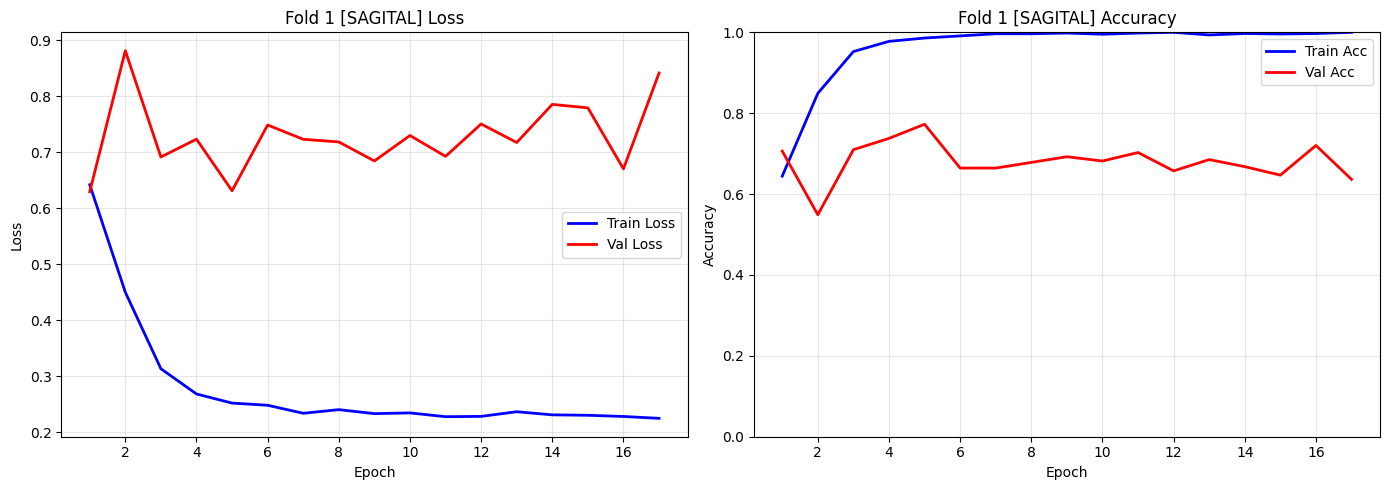


FOLD 1 VALIDATION SONUCLARI [SAGITAL]
  Val Accuracy  : 0.7727
  Precision     : 0.7746
  Recall        : 0.7727
  F1 Score      : 0.7720
  Per-Class F1  : CN=0.7566 | EMCI=0.7869 | Fark=0.0303 Normal
  Best Val Loss : 0.6312
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Sagital/sagital_fold_1.pth

FOLD 2 [SAGITAL]
  Train: 396 hasta / 1712 seans
  Val  : 70 hasta / 278 seans
  Train: CN=881 (51.5%) | EMCI=831 (48.5%)
  Val: CN=162 (58.3%) | EMCI=116 (41.7%)
Class Weights: CN=0.972, EMCI=1.030
[SAGITAL] Toplam param   : 7,216,770
[SAGITAL] Egitilen param : 2,423,042 (33.58%)
[SAGITAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6657 | Train Acc: 0.6297 | Val Loss: 0.6926 | Val Acc: 0.6187 | Val mF1: 0.6167 | LR_bb: 2.00e-04
         Val tahmin: CN=96, EMCI=182
  Epoch 02   | Train Loss: 0.4553 | Train Acc: 0.8405 | Val Loss: 0.8142 | Val Acc: 0.6151 | Val mF1: 0.6066 | LR_bb: 2.00e-04
  Epoch 03  

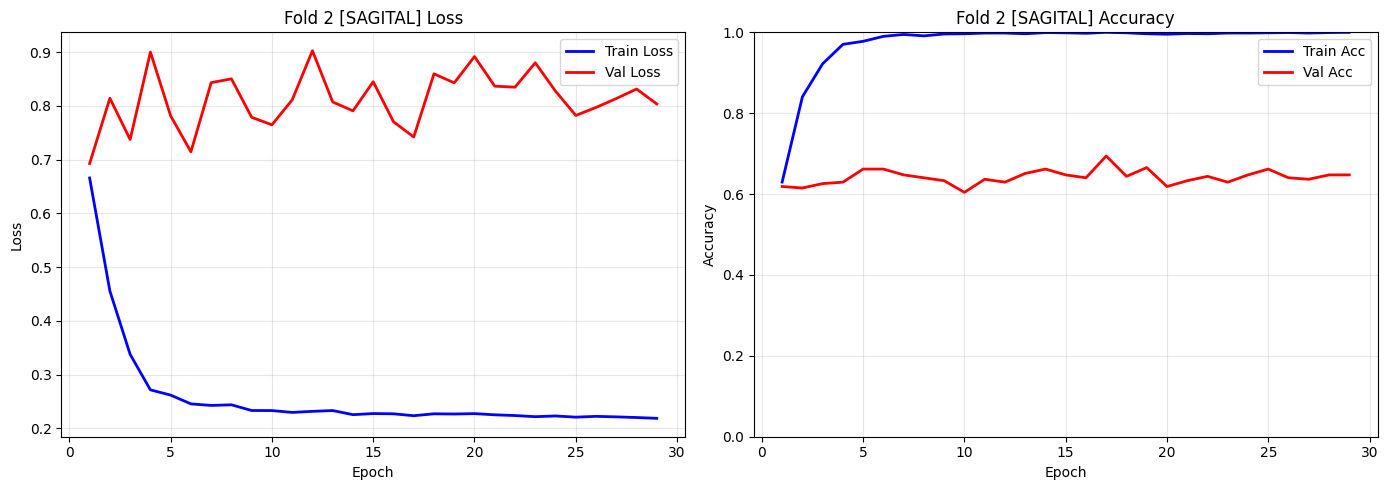


FOLD 2 VALIDATION SONUCLARI [SAGITAL]
  Val Accuracy  : 0.6942
  Precision     : 0.7048
  Recall        : 0.6942
  F1 Score      : 0.6963
  Per-Class F1  : CN=0.7213 | EMCI=0.6614 | Fark=0.0600 Normal
  Best Val Loss : 0.7420
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Sagital/sagital_fold_2.pth

FOLD 3 [SAGITAL]
  Train: 396 hasta / 1676 seans
  Val  : 70 hasta / 314 seans
  Train: CN=868 (51.8%) | EMCI=808 (48.2%)
  Val: CN=175 (55.7%) | EMCI=139 (44.3%)
Class Weights: CN=0.965, EMCI=1.037
[SAGITAL] Toplam param   : 7,216,770
[SAGITAL] Egitilen param : 2,423,042 (33.58%)
[SAGITAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6468 | Train Acc: 0.6539 | Val Loss: 0.6589 | Val Acc: 0.6529 | Val mF1: 0.6468 | LR_bb: 2.00e-04
         Val tahmin: CN=98, EMCI=216
  Epoch 02 * | Train Loss: 0.4643 | Train Acc: 0.8407 | Val Loss: 0.6270 | Val Acc: 0.7197 | Val mF1: 0.7192 | LR_bb: 2.00e-04
  Epoch 03  

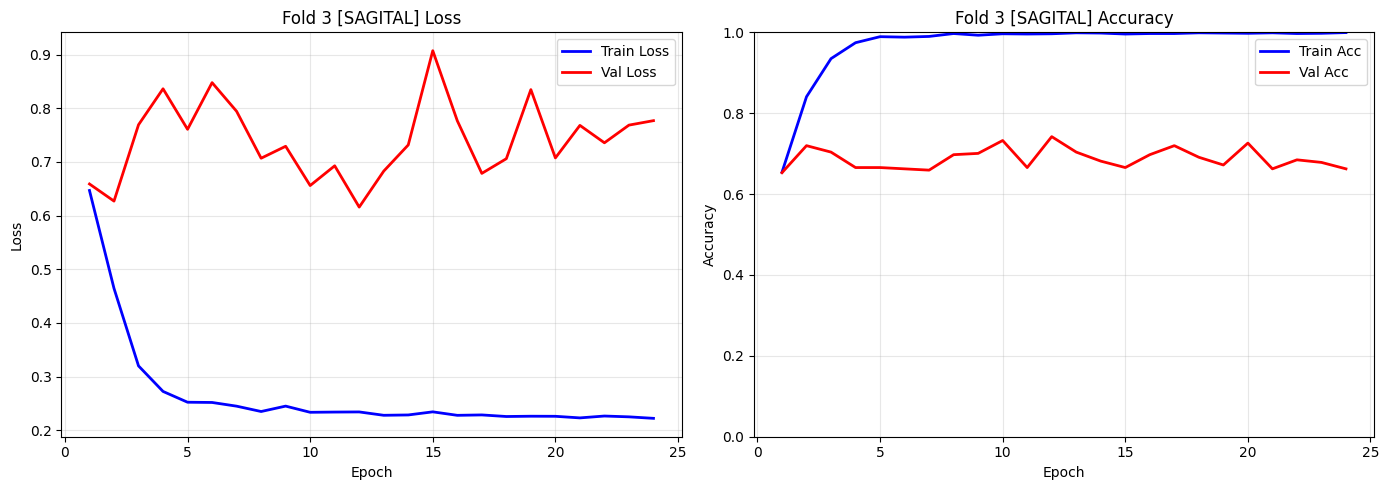


FOLD 3 VALIDATION SONUCLARI [SAGITAL]
  Val Accuracy  : 0.7420
  Precision     : 0.7411
  Recall        : 0.7420
  F1 Score      : 0.7410
  Per-Class F1  : CN=0.7744 | EMCI=0.6989 | Fark=0.0755 Normal
  Best Val Loss : 0.6158
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Sagital/sagital_fold_3.pth

FOLD 4 [SAGITAL]
  Train: 396 hasta / 1701 seans
  Val  : 70 hasta / 289 seans
  Train: CN=888 (52.2%) | EMCI=813 (47.8%)
  Val: CN=155 (53.6%) | EMCI=134 (46.4%)
Class Weights: CN=0.958, EMCI=1.046
[SAGITAL] Toplam param   : 7,216,770
[SAGITAL] Egitilen param : 2,423,042 (33.58%)
[SAGITAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6600 | Train Acc: 0.6143 | Val Loss: 0.6085 | Val Acc: 0.6886 | Val mF1: 0.6822 | LR_bb: 2.00e-04
         Val tahmin: CN=93, EMCI=196
  Epoch 02   | Train Loss: 0.4788 | Train Acc: 0.8230 | Val Loss: 0.7856 | Val Acc: 0.5675 | Val mF1: 0.5163 | LR_bb: 2.00e-04
  Epoch 03  

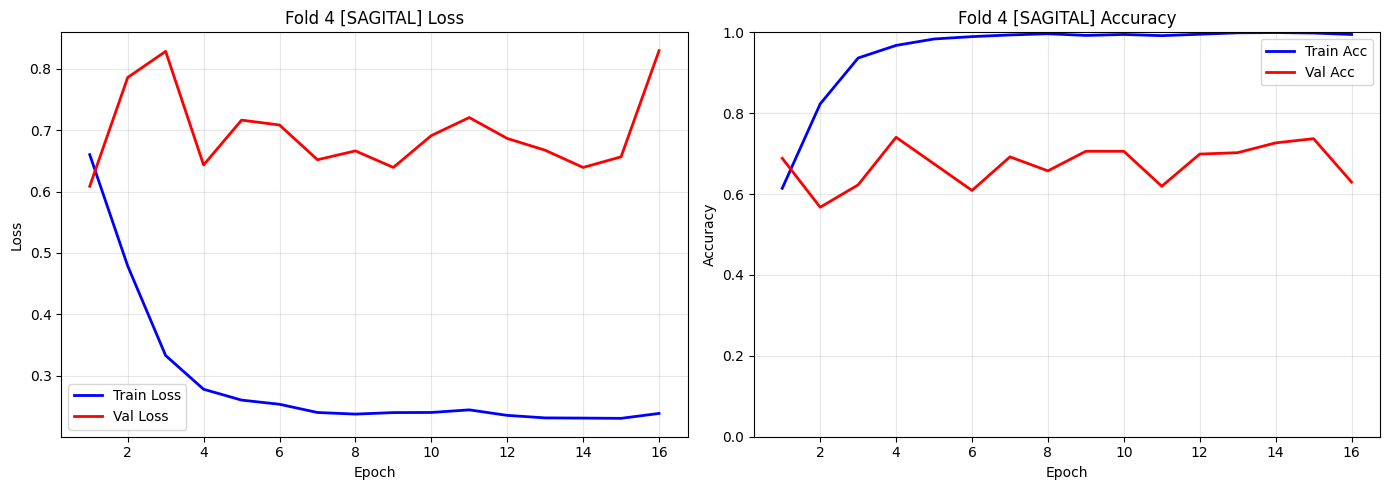


FOLD 4 VALIDATION SONUCLARI [SAGITAL]
  Val Accuracy  : 0.7405
  Precision     : 0.7441
  Recall        : 0.7405
  F1 Score      : 0.7408
  Per-Class F1  : CN=0.7475 | EMCI=0.7331 | Fark=0.0144 Normal
  Best Val Loss : 0.6432
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Sagital/sagital_fold_4.pth

FOLD 5 [SAGITAL]
  Train: 396 hasta / 1714 seans
  Val  : 70 hasta / 276 seans
  Train: CN=923 (53.9%) | EMCI=791 (46.1%)
  Val: CN=120 (43.5%) | EMCI=156 (56.5%)
Class Weights: CN=0.928, EMCI=1.083
[SAGITAL] Toplam param   : 7,216,770
[SAGITAL] Egitilen param : 2,423,042 (33.58%)
[SAGITAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6680 | Train Acc: 0.6441 | Val Loss: 0.7363 | Val Acc: 0.5688 | Val mF1: 0.5687 | LR_bb: 2.00e-04
         Val tahmin: CN=161, EMCI=115
  Epoch 02 * | Train Loss: 0.4211 | Train Acc: 0.8565 | Val Loss: 1.0478 | Val Acc: 0.6775 | Val mF1: 0.6153 | LR_bb: 2.00e-04
  Epoch 03 

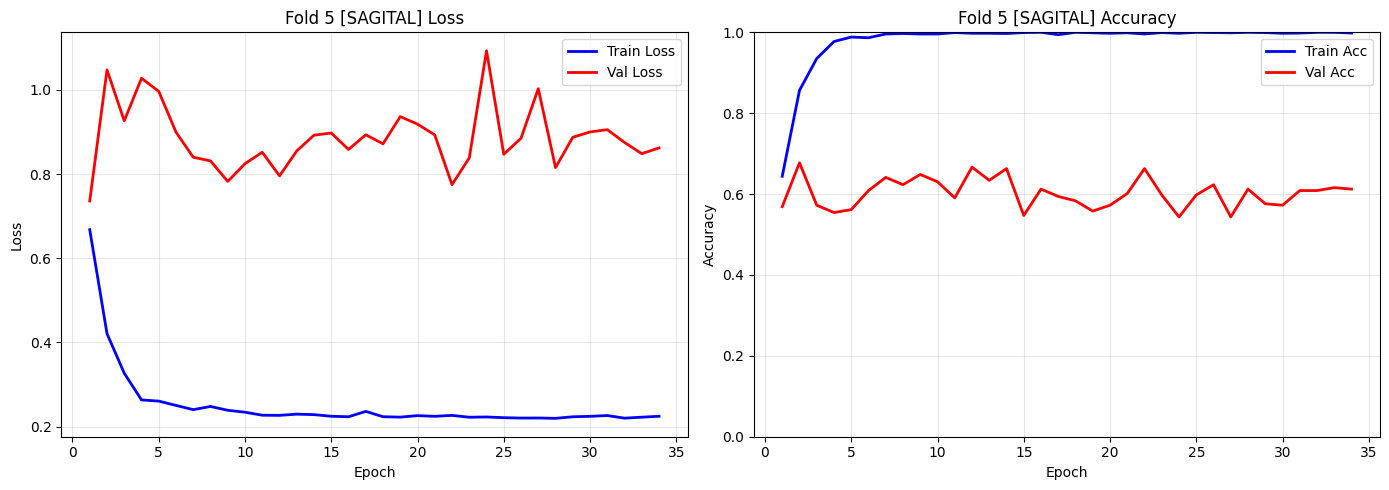


FOLD 5 VALIDATION SONUCLARI [SAGITAL]
  Val Accuracy  : 0.6630
  Precision     : 0.6641
  Recall        : 0.6630
  F1 Score      : 0.6635
  Per-Class F1  : CN=0.6173 | EMCI=0.6990 | Fark=0.0817 Normal
  Best Val Loss : 0.7750
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Sagital/sagital_fold_5.pth

SAGITAL 5-FOLD VALIDATION SONUCLARI:
 fold  val_acc   val_f1  best_val_loss
    1 0.772727 0.772038       0.631201
    2 0.694245 0.696293       0.742029
    3 0.742038 0.740956       0.615796
    4 0.740484 0.740808       0.643202
    5 0.663043 0.663488       0.775050
Ortalama Val Acc: 0.7225 +/- 0.0435
Sure: 27.5 dakika


In [ ]:
import time

sagital_klasoru = os.path.join(ANA_KLASOR, "Sagital")

print(f"EGITIM 1/3: SAGITAL")
print(f"Klasor: {sagital_klasoru}\n")

t0 = time.time()
sonuclar_sagital = duzlem_egit(tum_veriler, 'sagital', CONFIG, sagital_klasoru)
sure_sagital = time.time() - t0

df_sagital = pd.read_csv(os.path.join(sagital_klasoru, 'deney_sonuclari.csv'))
print(f"\nSAGITAL 5-FOLD VALIDATION SONUCLARI:")
print(df_sagital[['fold', 'val_acc', 'val_f1', 'best_val_loss']].to_string(index=False))
print(f"Ortalama Val Acc: {df_sagital['val_acc'].mean():.4f} +/- {df_sagital['val_acc'].std():.4f}")
print(f"Sure: {sure_sagital/60:.1f} dakika")

EGITIM 1/3: SAGITAL
Klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Sagital


DUZLEM: SAGITAL
Klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Sagital

FOLD 1 [SAGITAL]
  Train: 396 hasta / 1704 seans
  Val  : 70 hasta / 286 seans
  Train: CN=903 (53.0%) | EMCI=801 (47.0%)
  Val: CN=140 (49.0%) | EMCI=146 (51.0%)
Class Weights: CN=0.944, EMCI=1.064
[SAGITAL] Toplam param   : 7,216,770
[SAGITAL] Egitilen param : 2,423,042 (33.58%)
[SAGITAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6258 | Train Acc: 0.6678 | Val Loss: 0.6219 | Val Acc: 0.7168 | Val mF1: 0.7164 | LR_bb: 2.00e-04
         Val tahmin: CN=157, EMCI=129
  Epoch 02   | Train Loss: 0.4603 | Train Acc: 0.8369 | Val Loss: 0.7283 | Val Acc: 0.6958 | Val mF1: 0.6823 | LR_bb: 2.00e-04
  Epoch 03   | Train Loss: 0.3018 | Train Acc: 0.9542 | Val Loss: 0.8390 | Val Acc: 0.6049 | Val mF1: 

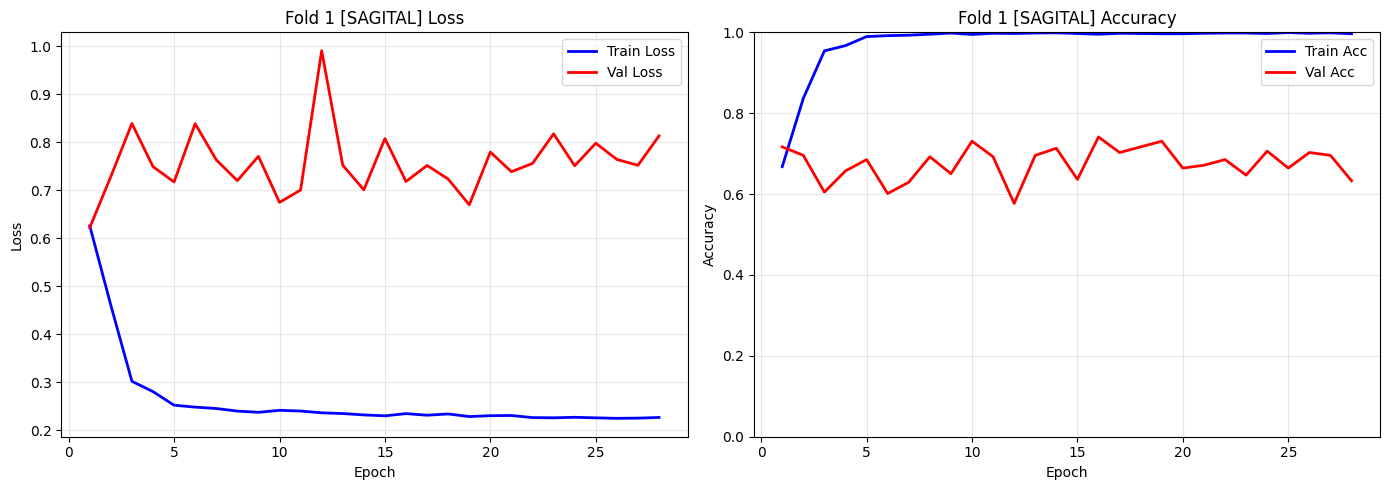


FOLD 1 VALIDATION SONUCLARI [SAGITAL]
  Val Accuracy  : 0.7413
  Precision     : 0.7485
  Recall        : 0.7413
  F1 Score      : 0.7386
  Per-Class F1  : CN=0.7087 | EMCI=0.7673 | Fark=0.0586 Normal
  Best Val Loss : 0.7181
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Sagital/sagital_fold_1.pth

FOLD 2 [SAGITAL]
  Train: 396 hasta / 1712 seans
  Val  : 70 hasta / 278 seans
  Train: CN=881 (51.5%) | EMCI=831 (48.5%)
  Val: CN=162 (58.3%) | EMCI=116 (41.7%)
Class Weights: CN=0.972, EMCI=1.030
[SAGITAL] Toplam param   : 7,216,770
[SAGITAL] Egitilen param : 2,423,042 (33.58%)
[SAGITAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6443 | Train Acc: 0.6244 | Val Loss: 0.6152 | Val Acc: 0.6439 | Val mF1: 0.6428 | LR_bb: 2.00e-04
         Val tahmin: CN=131, EMCI=147
  Epoch 02 * | Train Loss: 0.4680 | Train Acc: 0.8318 | Val Loss: 0.7724 | Val Acc: 0.6439 | Val mF1: 0.6431 | LR_bb: 2.00e-04
  Epoch 03 

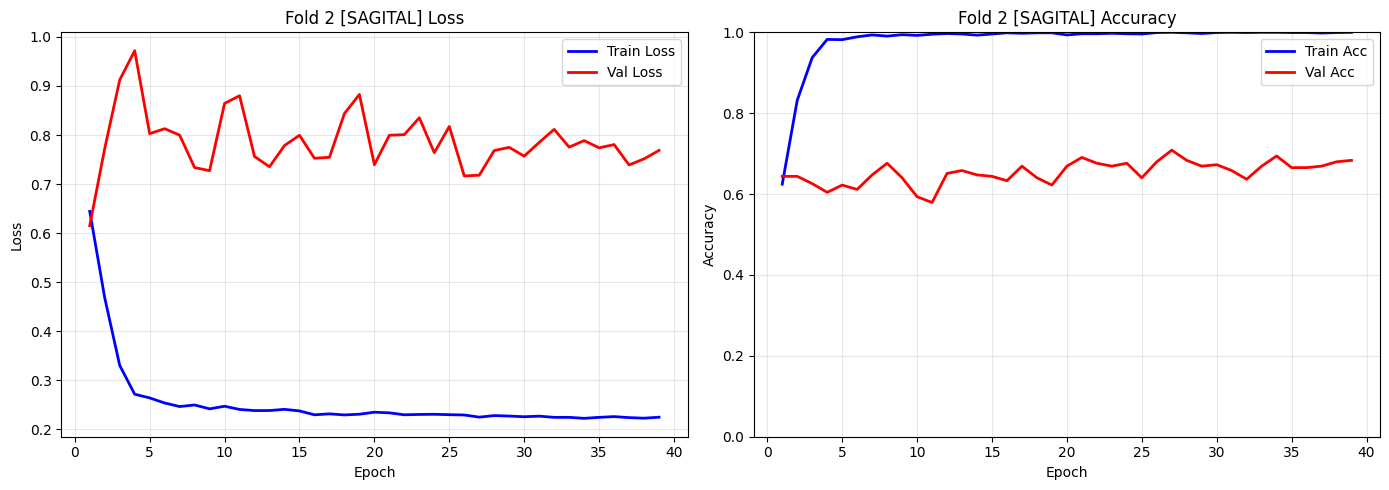


FOLD 2 VALIDATION SONUCLARI [SAGITAL]
  Val Accuracy  : 0.7086
  Precision     : 0.7107
  Recall        : 0.7086
  F1 Score      : 0.7094
  Per-Class F1  : CN=0.7461 | EMCI=0.6582 | Fark=0.0879 Normal
  Best Val Loss : 0.7180
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Sagital/sagital_fold_2.pth

FOLD 3 [SAGITAL]
  Train: 396 hasta / 1676 seans
  Val  : 70 hasta / 314 seans
  Train: CN=868 (51.8%) | EMCI=808 (48.2%)
  Val: CN=175 (55.7%) | EMCI=139 (44.3%)
Class Weights: CN=0.965, EMCI=1.037
[SAGITAL] Toplam param   : 7,216,770
[SAGITAL] Egitilen param : 2,423,042 (33.58%)
[SAGITAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6650 | Train Acc: 0.6295 | Val Loss: 0.6561 | Val Acc: 0.6465 | Val mF1: 0.6430 | LR_bb: 2.00e-04
         Val tahmin: CN=170, EMCI=144
  Epoch 02 * | Train Loss: 0.4346 | Train Acc: 0.8586 | Val Loss: 0.8444 | Val Acc: 0.6656 | Val mF1: 0.6592 | LR_bb: 2.00e-04
  Epoch 03 

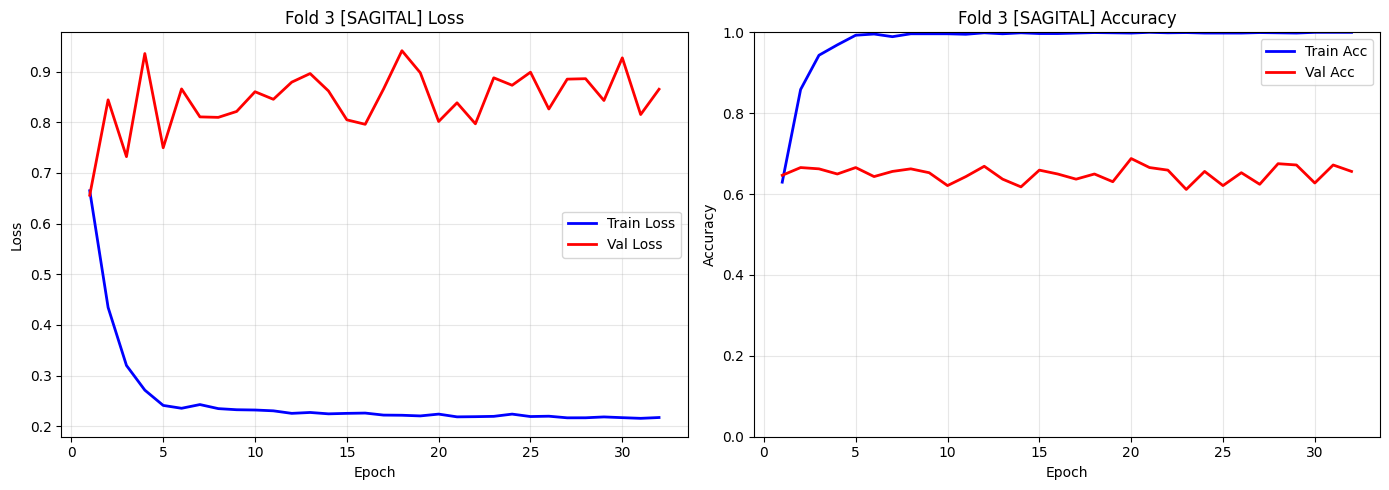


FOLD 3 VALIDATION SONUCLARI [SAGITAL]
  Val Accuracy  : 0.6879
  Precision     : 0.6871
  Recall        : 0.6879
  F1 Score      : 0.6874
  Per-Class F1  : CN=0.7232 | EMCI=0.6423 | Fark=0.0808 Normal
  Best Val Loss : 0.8017
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Sagital/sagital_fold_3.pth

FOLD 4 [SAGITAL]
  Train: 396 hasta / 1701 seans
  Val  : 70 hasta / 289 seans
  Train: CN=888 (52.2%) | EMCI=813 (47.8%)
  Val: CN=155 (53.6%) | EMCI=134 (46.4%)
Class Weights: CN=0.958, EMCI=1.046
[SAGITAL] Toplam param   : 7,216,770
[SAGITAL] Egitilen param : 2,423,042 (33.58%)
[SAGITAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6465 | Train Acc: 0.6543 | Val Loss: 0.5914 | Val Acc: 0.7682 | Val mF1: 0.7641 | LR_bb: 2.00e-04
         Val tahmin: CN=172, EMCI=117
  Epoch 02   | Train Loss: 0.4305 | Train Acc: 0.8601 | Val Loss: 0.7645 | Val Acc: 0.6851 | Val mF1: 0.6776 | LR_bb: 2.00e-04
  Epoch 03 

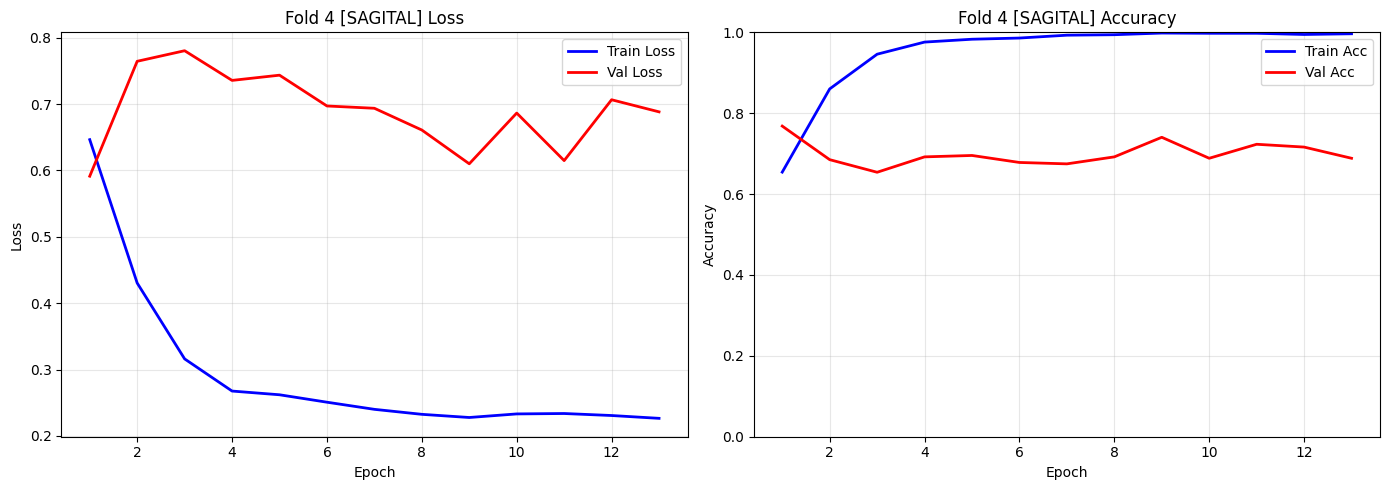


FOLD 4 VALIDATION SONUCLARI [SAGITAL]
  Val Accuracy  : 0.7682
  Precision     : 0.7700
  Recall        : 0.7682
  F1 Score      : 0.7663
  Per-Class F1  : CN=0.7951 | EMCI=0.7331 | Fark=0.0620 Normal
  Best Val Loss : 0.5914
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Sagital/sagital_fold_4.pth

FOLD 5 [SAGITAL]
  Train: 396 hasta / 1714 seans
  Val  : 70 hasta / 276 seans
  Train: CN=923 (53.9%) | EMCI=791 (46.1%)
  Val: CN=120 (43.5%) | EMCI=156 (56.5%)
Class Weights: CN=0.928, EMCI=1.083
[SAGITAL] Toplam param   : 7,216,770
[SAGITAL] Egitilen param : 2,423,042 (33.58%)
[SAGITAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6462 | Train Acc: 0.6354 | Val Loss: 0.8412 | Val Acc: 0.4891 | Val mF1: 0.4298 | LR_bb: 2.00e-04
         Val tahmin: CN=245, EMCI=31
  Epoch 02 * | Train Loss: 0.4385 | Train Acc: 0.8559 | Val Loss: 1.0689 | Val Acc: 0.6341 | Val mF1: 0.5318 | LR_bb: 2.00e-04
  Epoch 03 *

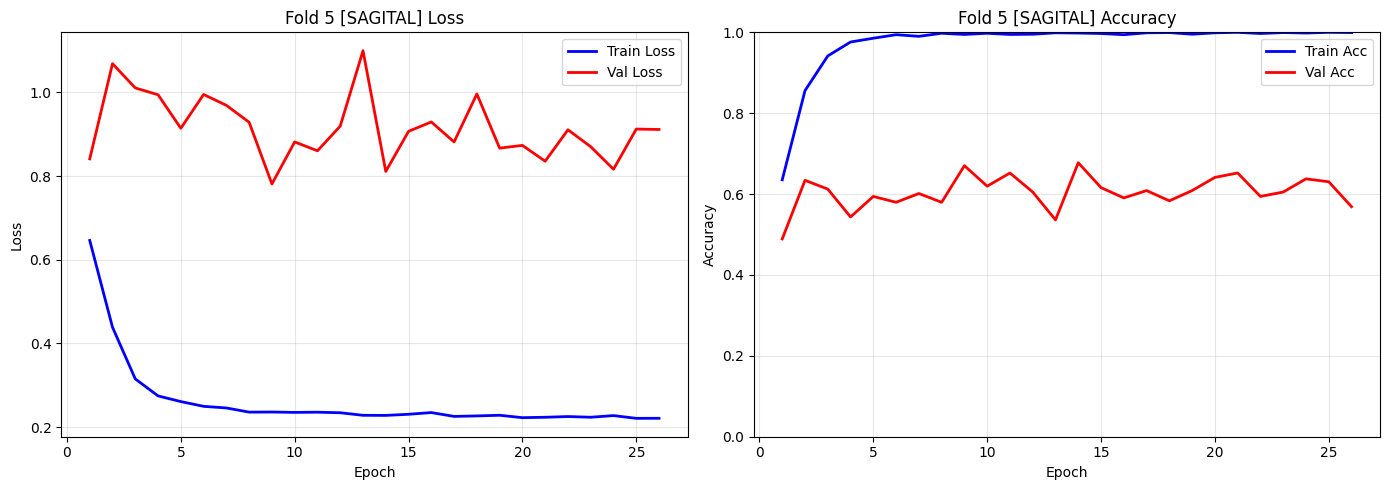


FOLD 5 VALIDATION SONUCLARI [SAGITAL]
  Val Accuracy  : 0.6775
  Precision     : 0.6753
  Recall        : 0.6775
  F1 Score      : 0.6715
  Per-Class F1  : CN=0.5899 | EMCI=0.7343 | Fark=0.1445 KONTROL ET
  Best Val Loss : 0.8111
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Sagital/sagital_fold_5.pth

SAGITAL 5-FOLD VALIDATION SONUCLARI:
 fold  val_acc   val_f1  best_val_loss
    1 0.741259 0.738594       0.718067
    2 0.708633 0.709423       0.718027
    3 0.687898 0.687383       0.801683
    4 0.768166 0.766341       0.591381
    5 0.677536 0.671517       0.811142
Ortalama Val Acc: 0.7167 +/- 0.0377
Sure: 31.8 dakika


In [ ]:
import time

sagital_klasoru = os.path.join(ANA_KLASOR, "Sagital")

print(f"EGITIM 1/3: SAGITAL")
print(f"Klasor: {sagital_klasoru}\n")

t0 = time.time()
sonuclar_sagital = duzlem_egit(tum_veriler, 'sagital', CONFIG, sagital_klasoru)
sure_sagital = time.time() - t0

df_sagital = pd.read_csv(os.path.join(sagital_klasoru, 'deney_sonuclari.csv'))
print(f"\nSAGITAL 5-FOLD VALIDATION SONUCLARI:")
print(df_sagital[['fold', 'val_acc', 'val_f1', 'best_val_loss']].to_string(index=False))
print(f"Ortalama Val Acc: {df_sagital['val_acc'].mean():.4f} +/- {df_sagital['val_acc'].std():.4f}")
print(f"Sure: {sure_sagital/60:.1f} dakika")

EGITIM 2/3: AKSIYAL
Klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Aksiyal


DUZLEM: AKSIYAL
Klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Aksiyal

FOLD 1 [AKSIYAL]
  Train: 396 hasta / 1704 seans
  Val  : 70 hasta / 286 seans
  Train: CN=903 (53.0%) | EMCI=801 (47.0%)
  Val: CN=140 (49.0%) | EMCI=146 (51.0%)
Class Weights: CN=0.944, EMCI=1.064
[AKSIYAL] Toplam param   : 7,216,770
[AKSIYAL] Egitilen param : 2,423,042 (33.58%)
[AKSIYAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6591 | Train Acc: 0.6350 | Val Loss: 0.7697 | Val Acc: 0.6014 | Val mF1: 0.6009 | LR_bb: 2.00e-04
         Val tahmin: CN=156, EMCI=130
  Epoch 02 * | Train Loss: 0.4586 | Train Acc: 0.8363 | Val Loss: 0.6857 | Val Acc: 0.6783 | Val mF1: 0.6737 | LR_bb: 2.00e-04
  Epoch 03   | Train Loss: 0.3463 | Train Acc: 0.9272 | Val Loss: 0.8154 | Val Acc: 0.6049 | Val mF1: 

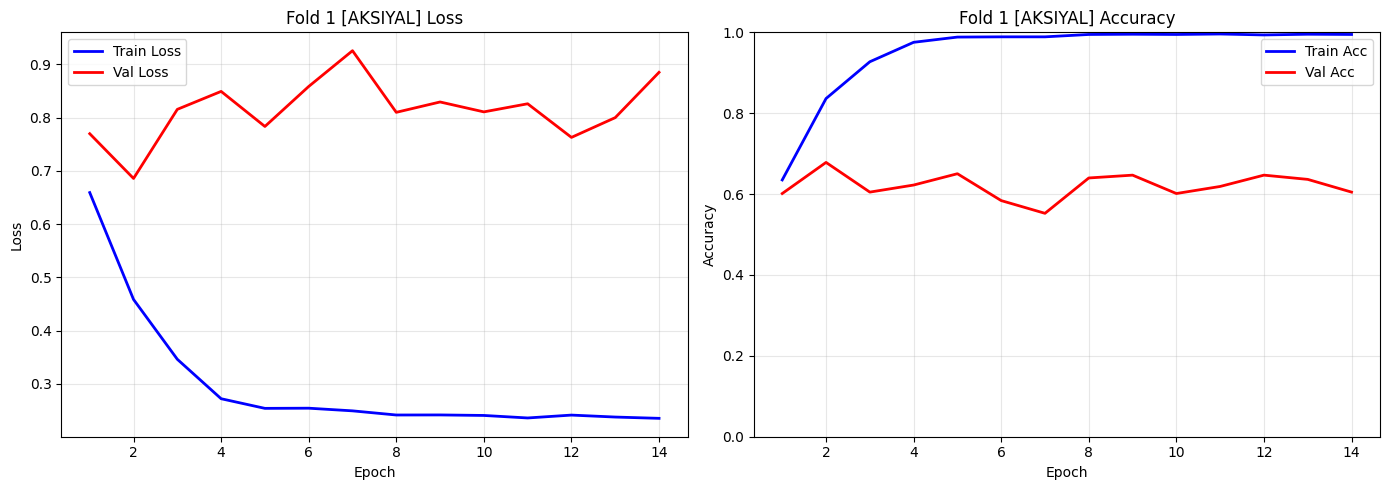


FOLD 1 VALIDATION SONUCLARI [AKSIYAL]
  Val Accuracy  : 0.6783
  Precision     : 0.6841
  Recall        : 0.6783
  F1 Score      : 0.6745
  Per-Class F1  : CN=0.6349 | EMCI=0.7125 | Fark=0.0776 Normal
  Best Val Loss : 0.6857
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Aksiyal/aksiyal_fold_1.pth

FOLD 2 [AKSIYAL]
  Train: 396 hasta / 1712 seans
  Val  : 70 hasta / 278 seans
  Train: CN=881 (51.5%) | EMCI=831 (48.5%)
  Val: CN=162 (58.3%) | EMCI=116 (41.7%)
Class Weights: CN=0.972, EMCI=1.030
[AKSIYAL] Toplam param   : 7,216,770
[AKSIYAL] Egitilen param : 2,423,042 (33.58%)
[AKSIYAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6727 | Train Acc: 0.6308 | Val Loss: 0.6591 | Val Acc: 0.5827 | Val mF1: 0.5813 | LR_bb: 2.00e-04
         Val tahmin: CN=100, EMCI=178
  Epoch 02   | Train Loss: 0.4799 | Train Acc: 0.8160 | Val Loss: 0.8855 | Val Acc: 0.5504 | Val mF1: 0.4722 | LR_bb: 2.00e-04
  Epoch 03 

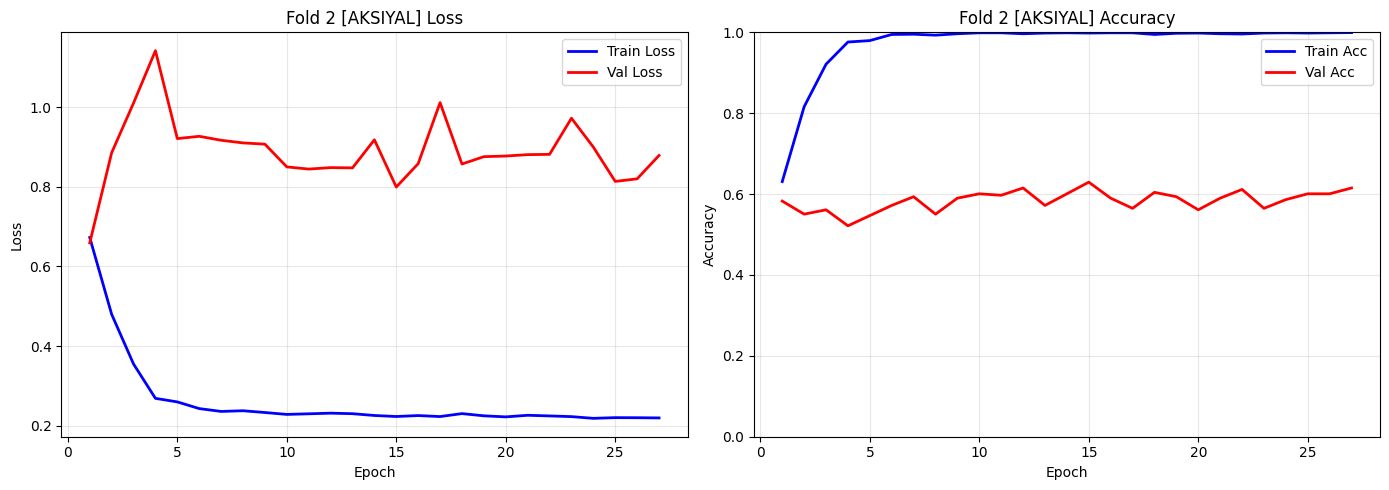


FOLD 2 VALIDATION SONUCLARI [AKSIYAL]
  Val Accuracy  : 0.6295
  Precision     : 0.6417
  Recall        : 0.6295
  F1 Score      : 0.6320
  Per-Class F1  : CN=0.6601 | EMCI=0.5929 | Fark=0.0672 Normal
  Best Val Loss : 0.7996
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Aksiyal/aksiyal_fold_2.pth

FOLD 3 [AKSIYAL]
  Train: 396 hasta / 1676 seans
  Val  : 70 hasta / 314 seans
  Train: CN=868 (51.8%) | EMCI=808 (48.2%)
  Val: CN=175 (55.7%) | EMCI=139 (44.3%)
Class Weights: CN=0.965, EMCI=1.037
[AKSIYAL] Toplam param   : 7,216,770
[AKSIYAL] Egitilen param : 2,423,042 (33.58%)
[AKSIYAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6893 | Train Acc: 0.5990 | Val Loss: 0.6402 | Val Acc: 0.6720 | Val mF1: 0.6600 | LR_bb: 2.00e-04
         Val tahmin: CN=198, EMCI=116
  Epoch 02   | Train Loss: 0.5003 | Train Acc: 0.7942 | Val Loss: 0.7076 | Val Acc: 0.6433 | Val mF1: 0.5934 | LR_bb: 2.00e-04
  Epoch 03 

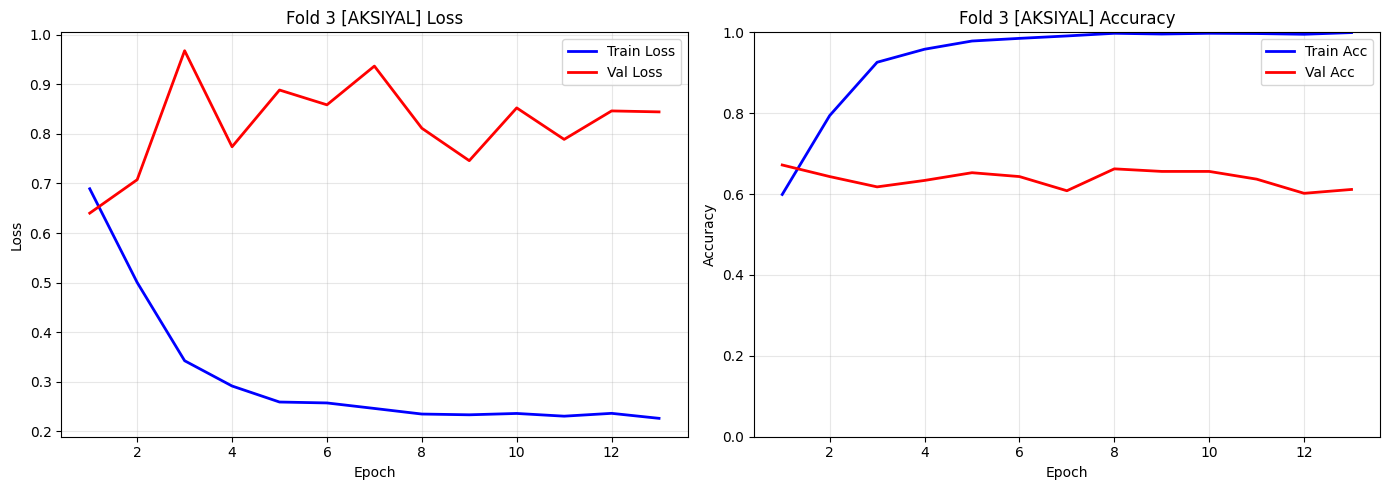


FOLD 3 VALIDATION SONUCLARI [AKSIYAL]
  Val Accuracy  : 0.6720
  Precision     : 0.6700
  Recall        : 0.6720
  F1 Score      : 0.6673
  Per-Class F1  : CN=0.7239 | EMCI=0.5961 | Fark=0.1278 KONTROL ET
  Best Val Loss : 0.6402
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Aksiyal/aksiyal_fold_3.pth

FOLD 4 [AKSIYAL]
  Train: 396 hasta / 1701 seans
  Val  : 70 hasta / 289 seans
  Train: CN=888 (52.2%) | EMCI=813 (47.8%)
  Val: CN=155 (53.6%) | EMCI=134 (46.4%)
Class Weights: CN=0.958, EMCI=1.046
[AKSIYAL] Toplam param   : 7,216,770
[AKSIYAL] Egitilen param : 2,423,042 (33.58%)
[AKSIYAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6809 | Train Acc: 0.6102 | Val Loss: 0.6188 | Val Acc: 0.6747 | Val mF1: 0.6699 | LR_bb: 2.00e-04
         Val tahmin: CN=99, EMCI=190
  Epoch 02 * | Train Loss: 0.4803 | Train Acc: 0.8125 | Val Loss: 0.7776 | Val Acc: 0.6990 | Val mF1: 0.6989 | LR_bb: 2.00e-04
  Epoch 

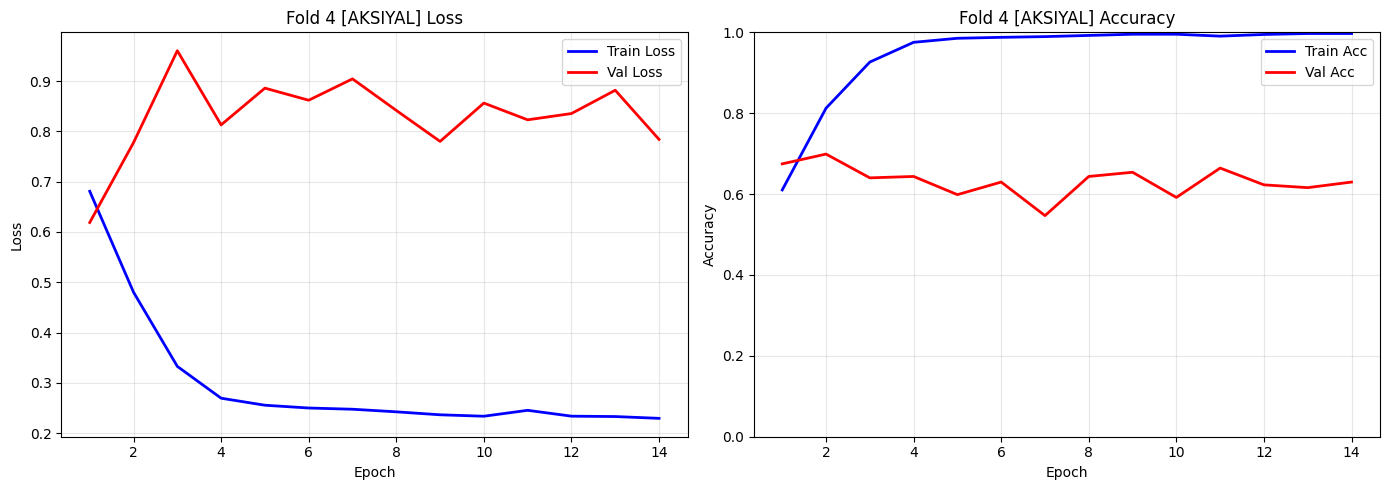


FOLD 4 VALIDATION SONUCLARI [AKSIYAL]
  Val Accuracy  : 0.6990
  Precision     : 0.7088
  Recall        : 0.6990
  F1 Score      : 0.6986
  Per-Class F1  : CN=0.6947 | EMCI=0.7031 | Fark=0.0083 Normal
  Best Val Loss : 0.7776
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Aksiyal/aksiyal_fold_4.pth

FOLD 5 [AKSIYAL]
  Train: 396 hasta / 1714 seans
  Val  : 70 hasta / 276 seans
  Train: CN=923 (53.9%) | EMCI=791 (46.1%)
  Val: CN=120 (43.5%) | EMCI=156 (56.5%)
Class Weights: CN=0.928, EMCI=1.083
[AKSIYAL] Toplam param   : 7,216,770
[AKSIYAL] Egitilen param : 2,423,042 (33.58%)
[AKSIYAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6672 | Train Acc: 0.6266 | Val Loss: 0.6740 | Val Acc: 0.6159 | Val mF1: 0.6156 | LR_bb: 2.00e-04
         Val tahmin: CN=164, EMCI=112
  Epoch 02 * | Train Loss: 0.4672 | Train Acc: 0.8407 | Val Loss: 0.6344 | Val Acc: 0.6812 | Val mF1: 0.6664 | LR_bb: 2.00e-04
  Epoch 03 

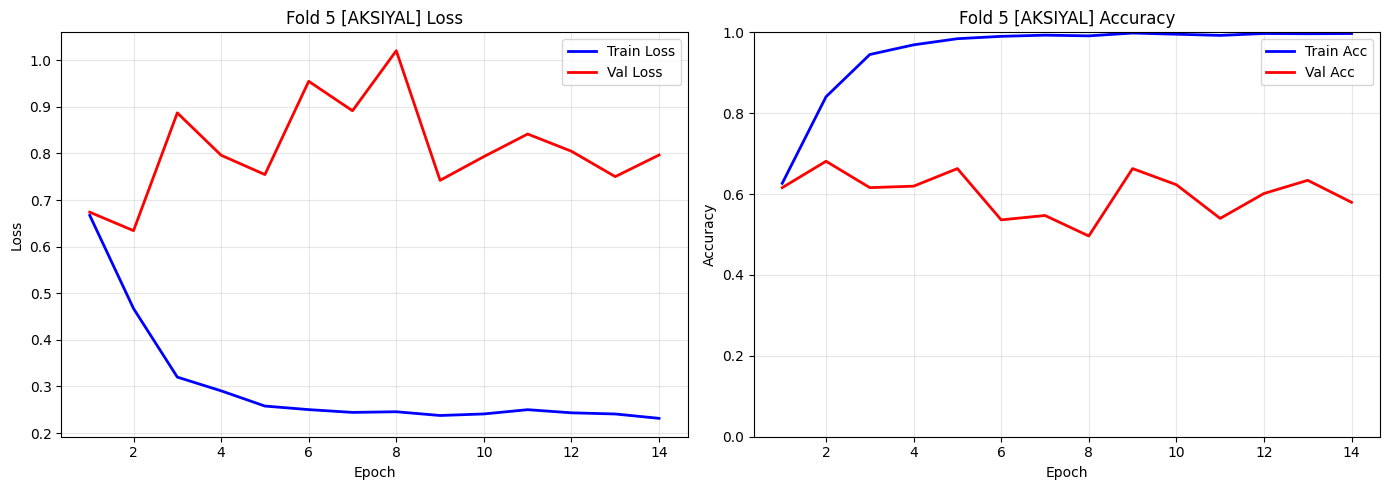


FOLD 5 VALIDATION SONUCLARI [AKSIYAL]
  Val Accuracy  : 0.6812
  Precision     : 0.6789
  Recall        : 0.6812
  F1 Score      : 0.6756
  Per-Class F1  : CN=0.5963 | EMCI=0.7365 | Fark=0.1402 KONTROL ET
  Best Val Loss : 0.6344
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Aksiyal/aksiyal_fold_5.pth

AKSIYAL 5-FOLD VALIDATION SONUCLARI:
 fold  val_acc   val_f1  best_val_loss
    1 0.678322 0.674524       0.685697
    2 0.629496 0.632034       0.799574
    3 0.671975 0.667295       0.640181
    4 0.698962 0.698601       0.777608
    5 0.681159 0.675572       0.634354
Ortalama Val Acc: 0.6720 +/- 0.0258
Sure: 19.0 dakika


In [ ]:
import time

aksiyal_klasoru = os.path.join(ANA_KLASOR, "Aksiyal")

print(f"EGITIM 2/3: AKSIYAL")
print(f"Klasor: {aksiyal_klasoru}\n")

t0 = time.time()
sonuclar_aksiyal = duzlem_egit(tum_veriler, 'aksiyal', CONFIG, aksiyal_klasoru)
sure_aksiyal = time.time() - t0

df_aksiyal = pd.read_csv(os.path.join(aksiyal_klasoru, 'deney_sonuclari.csv'))
print(f"\nAKSIYAL 5-FOLD VALIDATION SONUCLARI:")
print(df_aksiyal[['fold', 'val_acc', 'val_f1', 'best_val_loss']].to_string(index=False))
print(f"Ortalama Val Acc: {df_aksiyal['val_acc'].mean():.4f} +/- {df_aksiyal['val_acc'].std():.4f}")
print(f"Sure: {sure_aksiyal/60:.1f} dakika")

EGITIM 3/3: KORONAL
Klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Koronal


DUZLEM: KORONAL
Klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Koronal

FOLD 1 [KORONAL]
  Train: 396 hasta / 1704 seans
  Val  : 70 hasta / 286 seans
  Train: CN=903 (53.0%) | EMCI=801 (47.0%)
  Val: CN=140 (49.0%) | EMCI=146 (51.0%)
Class Weights: CN=0.944, EMCI=1.064
[KORONAL] Toplam param   : 7,216,770
[KORONAL] Egitilen param : 2,423,042 (33.58%)
[KORONAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6723 | Train Acc: 0.6285 | Val Loss: 0.5699 | Val Acc: 0.7343 | Val mF1: 0.7334 | LR_bb: 2.00e-04
         Val tahmin: CN=130, EMCI=156
  Epoch 02   | Train Loss: 0.4525 | Train Acc: 0.8457 | Val Loss: 0.7344 | Val Acc: 0.6294 | Val mF1: 0.6287 | LR_bb: 2.00e-04
  Epoch 03   | Train Loss: 0.3262 | Train Acc: 0.9419 | Val Loss: 0.8738 | Val Acc: 0.5909 | Val mF1: 

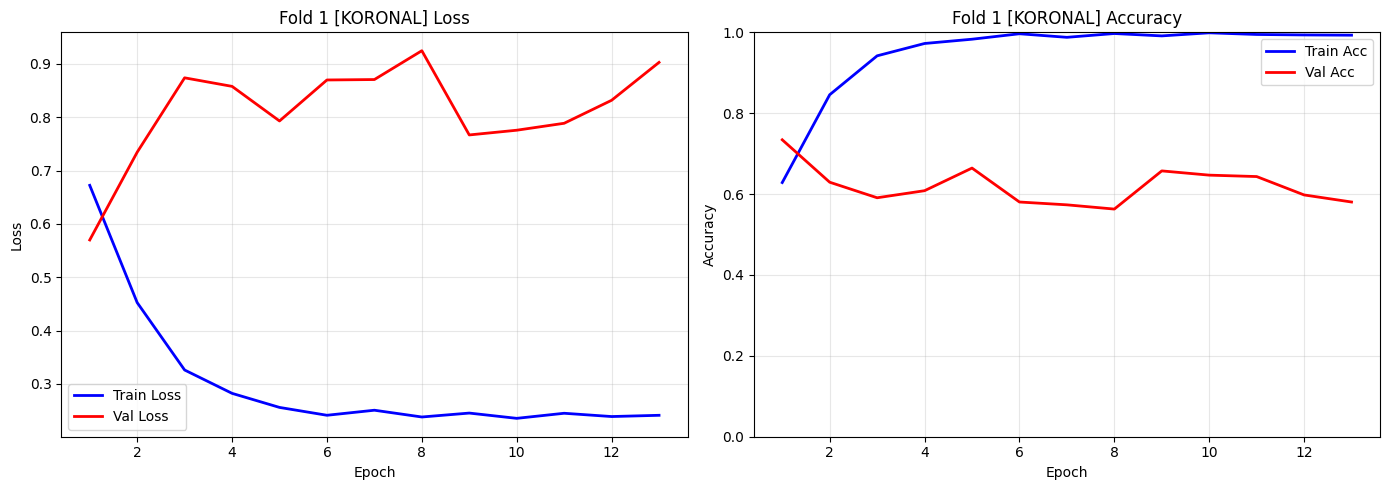


FOLD 1 VALIDATION SONUCLARI [KORONAL]
  Val Accuracy  : 0.7343
  Precision     : 0.7350
  Recall        : 0.7343
  F1 Score      : 0.7337
  Per-Class F1  : CN=0.7185 | EMCI=0.7483 | Fark=0.0298 Normal
  Best Val Loss : 0.5699
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Koronal/koronal_fold_1.pth

FOLD 2 [KORONAL]
  Train: 396 hasta / 1712 seans
  Val  : 70 hasta / 278 seans
  Train: CN=881 (51.5%) | EMCI=831 (48.5%)
  Val: CN=162 (58.3%) | EMCI=116 (41.7%)
Class Weights: CN=0.972, EMCI=1.030
[KORONAL] Toplam param   : 7,216,770
[KORONAL] Egitilen param : 2,423,042 (33.58%)
[KORONAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6621 | Train Acc: 0.6361 | Val Loss: 0.5856 | Val Acc: 0.6978 | Val mF1: 0.6976 | LR_bb: 2.00e-04
         Val tahmin: CN=124, EMCI=154
  Epoch 02   | Train Loss: 0.4878 | Train Acc: 0.8137 | Val Loss: 0.6578 | Val Acc: 0.6942 | Val mF1: 0.6918 | LR_bb: 2.00e-04
  Epoch 03 

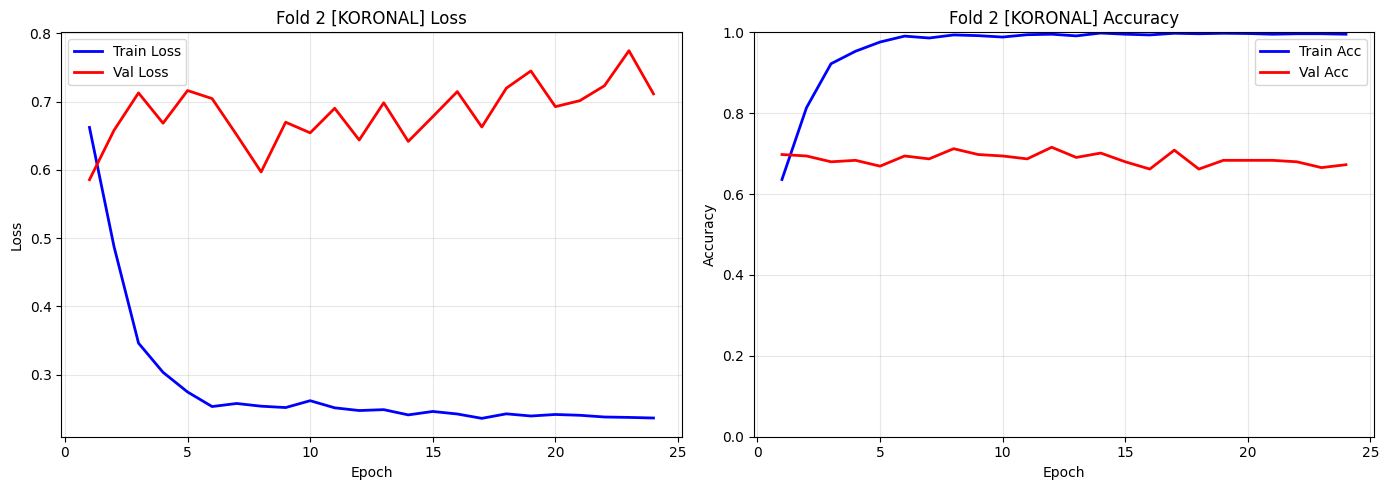


FOLD 2 VALIDATION SONUCLARI [KORONAL]
  Val Accuracy  : 0.7158
  Precision     : 0.7263
  Recall        : 0.7158
  F1 Score      : 0.7177
  Per-Class F1  : CN=0.7410 | EMCI=0.6853 | Fark=0.0557 Normal
  Best Val Loss : 0.6437
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Koronal/koronal_fold_2.pth

FOLD 3 [KORONAL]
  Train: 396 hasta / 1676 seans
  Val  : 70 hasta / 314 seans
  Train: CN=868 (51.8%) | EMCI=808 (48.2%)
  Val: CN=175 (55.7%) | EMCI=139 (44.3%)
Class Weights: CN=0.965, EMCI=1.037
[KORONAL] Toplam param   : 7,216,770
[KORONAL] Egitilen param : 2,423,042 (33.58%)
[KORONAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6706 | Train Acc: 0.6247 | Val Loss: 0.6567 | Val Acc: 0.6146 | Val mF1: 0.5721 | LR_bb: 2.00e-04
         Val tahmin: CN=238, EMCI=76
  Epoch 02 * | Train Loss: 0.4833 | Train Acc: 0.8061 | Val Loss: 0.6836 | Val Acc: 0.6688 | Val mF1: 0.6679 | LR_bb: 2.00e-04
  Epoch 03  

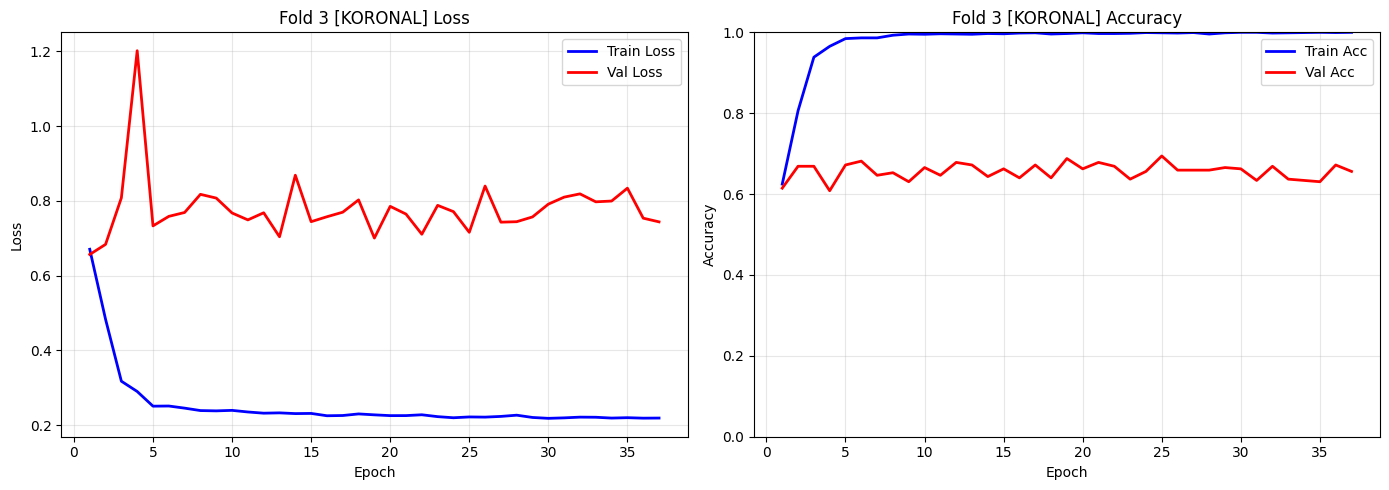


FOLD 3 VALIDATION SONUCLARI [KORONAL]
  Val Accuracy  : 0.6943
  Precision     : 0.6973
  Recall        : 0.6943
  F1 Score      : 0.6951
  Per-Class F1  : CN=0.7176 | EMCI=0.6667 | Fark=0.0510 Normal
  Best Val Loss : 0.7159
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Koronal/koronal_fold_3.pth

FOLD 4 [KORONAL]
  Train: 396 hasta / 1701 seans
  Val  : 70 hasta / 289 seans
  Train: CN=888 (52.2%) | EMCI=813 (47.8%)
  Val: CN=155 (53.6%) | EMCI=134 (46.4%)
Class Weights: CN=0.958, EMCI=1.046
[KORONAL] Toplam param   : 7,216,770
[KORONAL] Egitilen param : 2,423,042 (33.58%)
[KORONAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6704 | Train Acc: 0.6220 | Val Loss: 0.6442 | Val Acc: 0.6505 | Val mF1: 0.6313 | LR_bb: 2.00e-04
         Val tahmin: CN=200, EMCI=89
  Epoch 02   | Train Loss: 0.4689 | Train Acc: 0.8319 | Val Loss: 0.8854 | Val Acc: 0.5433 | Val mF1: 0.5103 | LR_bb: 2.00e-04
  Epoch 03  

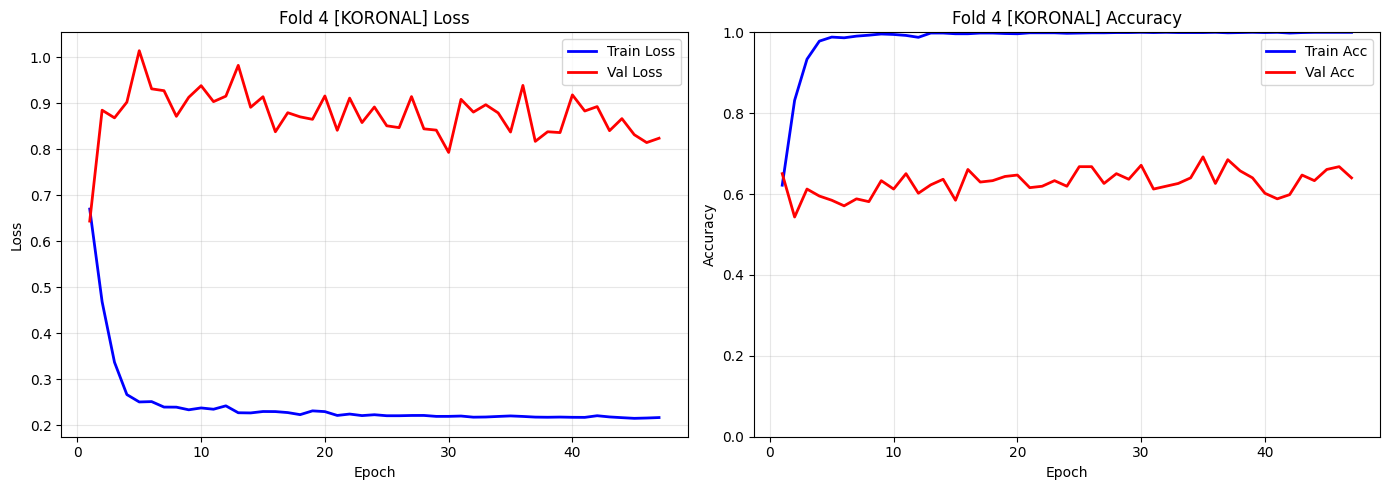


FOLD 4 VALIDATION SONUCLARI [KORONAL]
  Val Accuracy  : 0.6920
  Precision     : 0.6973
  Recall        : 0.6920
  F1 Score      : 0.6923
  Per-Class F1  : CN=0.6962 | EMCI=0.6877 | Fark=0.0085 Normal
  Best Val Loss : 0.8379
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Koronal/koronal_fold_4.pth

FOLD 5 [KORONAL]
  Train: 396 hasta / 1714 seans
  Val  : 70 hasta / 276 seans
  Train: CN=923 (53.9%) | EMCI=791 (46.1%)
  Val: CN=120 (43.5%) | EMCI=156 (56.5%)
Class Weights: CN=0.928, EMCI=1.083
[KORONAL] Toplam param   : 7,216,770
[KORONAL] Egitilen param : 2,423,042 (33.58%)
[KORONAL] Dropout        : 0.6
  Epoch 01 * | Train Loss: 0.6542 | Train Acc: 0.6266 | Val Loss: 0.6325 | Val Acc: 0.6413 | Val mF1: 0.6396 | LR_bb: 2.00e-04
         Val tahmin: CN=137, EMCI=139
  Epoch 02 * | Train Loss: 0.4726 | Train Acc: 0.8296 | Val Loss: 0.6231 | Val Acc: 0.6884 | Val mF1: 0.6874 | LR_bb: 2.00e-04
  Epoch 03 

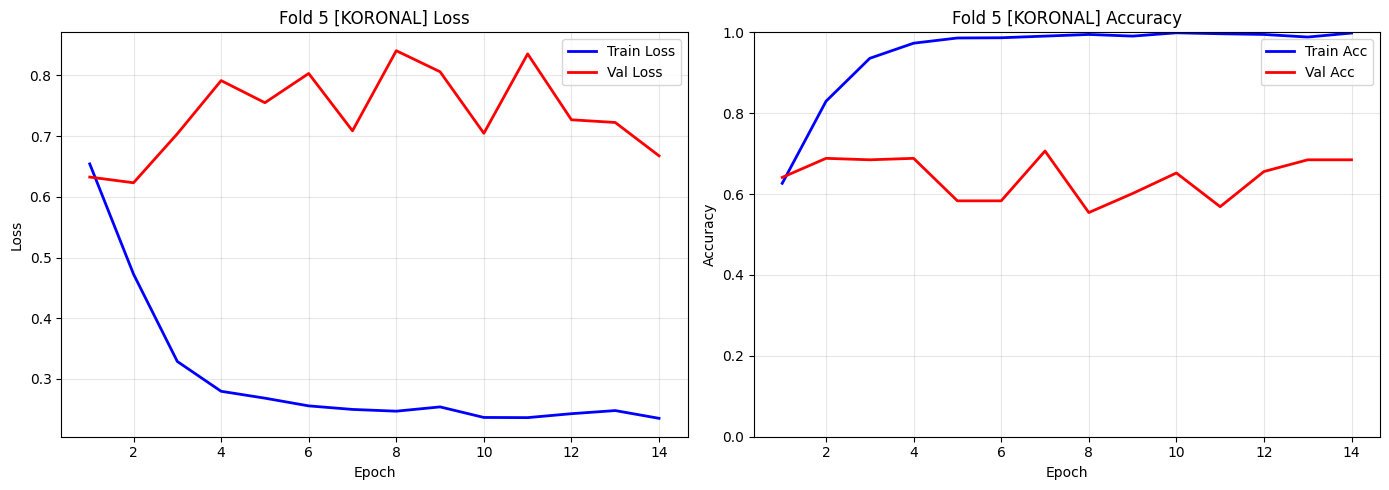


FOLD 5 VALIDATION SONUCLARI [KORONAL]
  Val Accuracy  : 0.6884
  Precision     : 0.6983
  Recall        : 0.6884
  F1 Score      : 0.6897
  Per-Class F1  : CN=0.6692 | EMCI=0.7055 | Fark=0.0362 Normal
  Best Val Loss : 0.6231
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Koronal/koronal_fold_5.pth

KORONAL 5-FOLD VALIDATION SONUCLARI:
 fold  val_acc   val_f1  best_val_loss
    1 0.734266 0.733744       0.569897
    2 0.715827 0.717732       0.643736
    3 0.694268 0.695079       0.715885
    4 0.692042 0.692292       0.837892
    5 0.688406 0.689719       0.623126
Ortalama Val Acc: 0.7050 +/- 0.0196
Sure: 30.8 dakika


In [ ]:
import time

koronal_klasoru = os.path.join(ANA_KLASOR, "Koronal")

print(f"EGITIM 3/3: KORONAL")
print(f"Klasor: {koronal_klasoru}\n")

t0 = time.time()
sonuclar_koronal = duzlem_egit(tum_veriler, 'koronal', CONFIG, koronal_klasoru)
sure_koronal = time.time() - t0

df_koronal = pd.read_csv(os.path.join(koronal_klasoru, 'deney_sonuclari.csv'))
print(f"\nKORONAL 5-FOLD VALIDATION SONUCLARI:")
print(df_koronal[['fold', 'val_acc', 'val_f1', 'best_val_loss']].to_string(index=False))
print(f"Ortalama Val Acc: {df_koronal['val_acc'].mean():.4f} +/- {df_koronal['val_acc'].std():.4f}")
print(f"Sure: {sure_koronal/60:.1f} dakika")

TOPLU VALIDATION SONUCLARI (Per-Plane)

--- SAGITAL ---
 fold  val_acc   val_f1  val_f1_cn  val_f1_emci  best_val_loss
    1 0.741259 0.738594   0.708661     0.767296       0.718067
    2 0.708633 0.709423   0.746082     0.658228       0.718027
    3 0.687898 0.687383   0.723164     0.642336       0.801683
    4 0.768166 0.766341   0.795107     0.733068       0.591381
    5 0.677536 0.671517   0.589862     0.734328       0.811142
  Ortalama Val Acc : 0.7167 +/- 0.0377
  Ortalama Val F1  : 0.7147
  CN F1 / EMCI F1  : 0.7126 / 0.7071

--- AKSIYAL ---
 fold  val_acc   val_f1  val_f1_cn  val_f1_emci  best_val_loss
    1 0.678322 0.674524   0.634921     0.712500       0.685697
    2 0.629496 0.632034   0.660066     0.592885       0.799574
    3 0.671975 0.667295   0.723861     0.596078       0.640181
    4 0.698962 0.698601   0.694737     0.703072       0.777608
    5 0.681159 0.675572   0.596330     0.736527       0.634354
  Ortalama Val Acc : 0.6720 +/- 0.0258
  Ortalama Val F1  : 0.6696


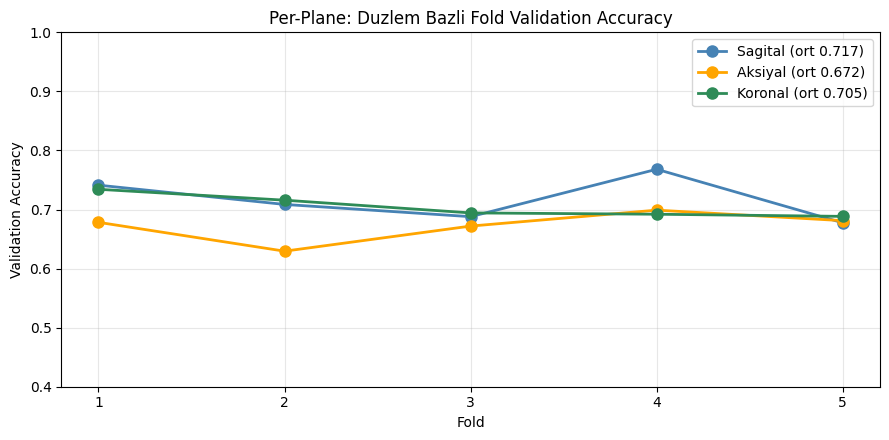

In [ ]:
# ===== TOPLU VALIDATION OZETI (3 duzlem x 5 fold) =====
import pandas as pd, os

# Modeller baska bir oturumda egitildiyse ANA_KLASOR'u elle sabitle:

duzlemler = {
    'Sagital': os.path.join(ANA_KLASOR, 'Sagital', 'deney_sonuclari.csv'),
    'Aksiyal': os.path.join(ANA_KLASOR, 'Aksiyal', 'deney_sonuclari.csv'),
    'Koronal': os.path.join(ANA_KLASOR, 'Koronal', 'deney_sonuclari.csv'),
}

tum_dfler = []
print("="*70)
print("TOPLU VALIDATION SONUCLARI (Per-Plane)")
print("="*70)

for ad, yol in duzlemler.items():
    if not os.path.exists(yol):
        print(f"\n[{ad}] CSV bulunamadi ({yol}) - bu duzlem egitilmemis olabilir.")
        continue
    df = pd.read_csv(yol)
    df['duzlem'] = ad
    tum_dfler.append(df)

    print(f"\n--- {ad.upper()} ---")
    print(df[['fold', 'val_acc', 'val_f1', 'val_f1_cn', 'val_f1_emci', 'best_val_loss']].to_string(index=False))
    print(f"  Ortalama Val Acc : {df['val_acc'].mean():.4f} +/- {df['val_acc'].std():.4f}")
    print(f"  Ortalama Val F1  : {df['val_f1'].mean():.4f}")
    print(f"  CN F1 / EMCI F1  : {df['val_f1_cn'].mean():.4f} / {df['val_f1_emci'].mean():.4f}")

if tum_dfler:
    hepsi = pd.concat(tum_dfler, ignore_index=True)

    print("\n" + "="*70)
    print("DUZLEM BAZLI OZET TABLOSU")
    print("="*70)
    ozet = hepsi.groupby('duzlem').agg(
        val_acc_ort=('val_acc', 'mean'),
        val_acc_std=('val_acc', 'std'),
        val_f1_ort=('val_f1', 'mean'),
        cn_f1=('val_f1_cn', 'mean'),
        emci_f1=('val_f1_emci', 'mean'),
    ).round(4)
    print(ozet.to_string())

    print("\n" + "="*70)
    print("GENEL ORTALAMA (15 model = 3 duzlem x 5 fold)")
    print("="*70)
    print(f"  Val Accuracy : {hepsi['val_acc'].mean():.4f} +/- {hepsi['val_acc'].std():.4f}")
    print(f"  Val F1       : {hepsi['val_f1'].mean():.4f} +/- {hepsi['val_f1'].std():.4f}")
    print(f"  CN F1        : {hepsi['val_f1_cn'].mean():.4f}")
    print(f"  EMCI F1      : {hepsi['val_f1_emci'].mean():.4f}")

    # Gorsel: duzlem bazli fold accuracy
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(9, 4.5))
    renkler = {'Sagital': 'steelblue', 'Aksiyal': 'orange', 'Koronal': 'seagreen'}
    for ad in ['Sagital', 'Aksiyal', 'Koronal']:
        d = hepsi[hepsi['duzlem'] == ad]
        if len(d) == 0: continue
        ax.plot(d['fold'], d['val_acc'], 'o-', label=f"{ad} (ort {d['val_acc'].mean():.3f})",
                color=renkler[ad], lw=2, markersize=8)
    ax.set_xlabel('Fold'); ax.set_ylabel('Validation Accuracy')
    ax.set_title('Per-Plane: Duzlem Bazli Fold Validation Accuracy')
    ax.set_xticks([1,2,3,4,5]); ax.set_ylim([0.4, 1.0])
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(ANA_KLASOR, 'toplu_val_accuracy.png'), dpi=100, bbox_inches='tight')
    plt.show()
else:
    print("\nHic CSV bulunamadi. Once egitimi calistir veya ANA_KLASOR'u dogru klasore sabitle.")

## NIHAI TEST — Izole Test Seti + Agirlikli Ensemble

Asagidaki hucre, egitime HIC girmemis izole test setini okur, kaydedilen
15 modeli (3 duzlem x 5 fold) yukler ve **agirlikli soft voting** ile
tek bir nihai tahmin uretir.

`DUZLEM_AGIRLIK` sozlugu ile her duzleme verilen agirligi degistirebilirsin.
Su an hepsi esit. Ornegin aksiyali zayiflatmak istersen:
`{'sagital': 1.0, 'aksiyal': 0.5, 'koronal': 1.0}` yapabilirsin.


TEST seti: 296 seans  (CN=148, EMCI=148)

[SAGITAL] 5 fold modeli test ediliyor...
  fold 1 tamam (/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Sagital/sagital_fold_1.pth)
  fold 2 tamam (/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Sagital/sagital_fold_2.pth)
  fold 3 tamam (/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Sagital/sagital_fold_3.pth)
  fold 4 tamam (/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Sagital/sagital_fold_4.pth)
  fold 5 tamam (/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04/Sagital/sagital_fold_5.pth)

[AKSIYAL] 5 fold modeli test ediliyor...
  fold 1 tamam (/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_Per

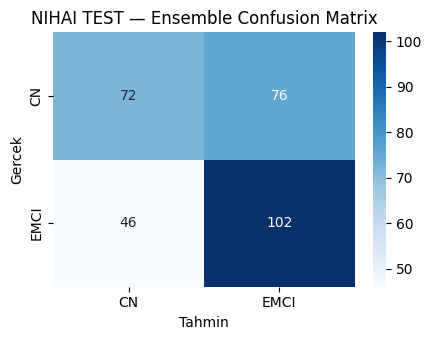

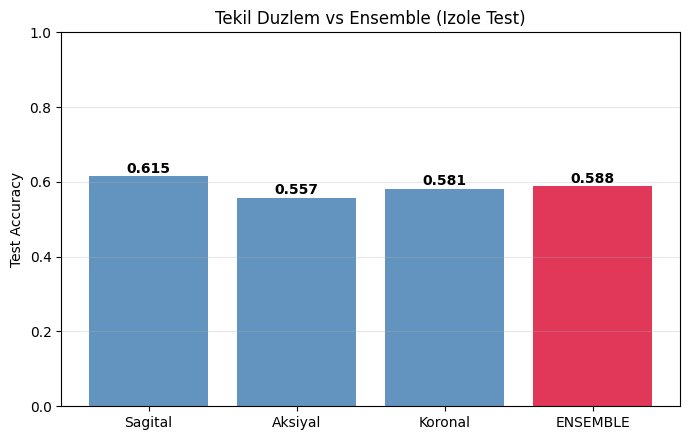


Kaydedildi: final_test_tahminler.csv, final_test_ozet.csv
Bitti.


In [ ]:
# ============================================================
# NIHAI TEST: izole test seti + 15 model agirlikli ensemble
# ============================================================
import numpy as np
ANA_KLASOR = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04'


# --- 1) Izole test verisini oku (train ile AYNI yapida) ---
test_config = dict(CONFIG)
test_config["kaynak_CN"]   = CONFIG["kaynak_CN_test"]
test_config["kaynak_EMCI"] = CONFIG["kaynak_EMCI_test"]

test_veriler = veri_listesi_olustur(test_config)
n_cn_te   = sum(1 for x in test_veriler if x['etiket'] == 0)
n_emci_te = sum(1 for x in test_veriler if x['etiket'] == 1)
print(f"TEST seti: {len(test_veriler)} seans  (CN={n_cn_te}, EMCI={n_emci_te})")
assert len(test_veriler) > 0, "Test seti bos! kaynak_CN_test / kaynak_EMCI_test yollarini kontrol et."

# Gercek etiket sozlugu: sid -> etiket
sid_true = {f"{x['hasta_id']}_{x['seans_id']}": x['etiket'] for x in test_veriler}

# --- 2) Ensemble agirliklari (degistirilebilir) ---
DUZLEM_AGIRLIK = {'sagital': 1.0, 'aksiyal': 1.0, 'koronal': 1.0}

DUZLEM_KLASOR = {
    'sagital': os.path.join(ANA_KLASOR, 'Sagital'),
    'aksiyal': os.path.join(ANA_KLASOR, 'Aksiyal'),
    'koronal': os.path.join(ANA_KLASOR, 'Koronal'),
}

# --- 3) Tahmin yardimci fonksiyonu (seans_id ile birlikte) ---
def tahmin_al(model, loader):
    model.eval()
    sids_all, probs_all = [], []
    with torch.no_grad():
        for sids, slices, lbls in loader:
            slices = slices.to(DEVICE)
            logits = model(slices)
            probs  = torch.softmax(logits, dim=1).cpu().numpy()
            sids_all.extend(list(sids))
            probs_all.extend(probs.tolist())
    return sids_all, probs_all

# --- 4) Her duzlem icin 5 fold modelin olasiligini ortala ---
# plane_avg[duzlem][sid] = ortalama [prob_cn, prob_emci]
plane_avg = {}

for duzlem, klasor in DUZLEM_KLASOR.items():
    print(f"\n[{duzlem.upper()}] 5 fold modeli test ediliyor...")
    test_loader = loader_olustur(test_veriler, duzlem, CONFIG, shuffle=False)

    toplam = {}   # sid -> np.array([p_cn, p_emci]) toplam
    for fold in range(1, CONFIG['k_fold'] + 1):
        m_path = os.path.join(klasor, f'{duzlem}_fold_{fold}.pth')
        model = SinglePlaneModel(dropout_rate=CONFIG['dropout'], hidden_dim=256).to(DEVICE)
        model.load_state_dict(torch.load(m_path, weights_only=True))
        sids, probs = tahmin_al(model, test_loader)
        for sid, pr in zip(sids, probs):
            toplam.setdefault(sid, np.zeros(2))
            toplam[sid] += np.array(pr)
        print(f"  fold {fold} tamam ({m_path})")
        del model
        torch.cuda.empty_cache()

    plane_avg[duzlem] = {sid: v / CONFIG['k_fold'] for sid, v in toplam.items()}

# --- 5) Agirlikli ensemble (3 duzlem) ---
toplam_agirlik = sum(DUZLEM_AGIRLIK.values())
ortak_sid = set.intersection(*[set(plane_avg[d].keys()) for d in DUZLEM_KLASOR])
print(f"\nUc duzlemde de tahmin edilen ortak seans: {len(ortak_sid)}")

y_true, y_pred = [], []
y_pred_duzlem = {d: [] for d in DUZLEM_KLASOR}
kayit = []

for sid in sorted(ortak_sid):
    fused = np.zeros(2)
    for d in DUZLEM_KLASOR:
        fused += DUZLEM_AGIRLIK[d] * plane_avg[d][sid]
    fused /= toplam_agirlik

    pred = int(np.argmax(fused))
    true = sid_true[sid]
    y_true.append(true)
    y_pred.append(pred)

    satir = {'seans_id': sid,
             'gercek': 'CN' if true == 0 else 'EMCI',
             'ens_prob_cn': fused[0], 'ens_prob_emci': fused[1],
             'ensemble': 'CN' if pred == 0 else 'EMCI'}
    for d in DUZLEM_KLASOR:
        dp = int(np.argmax(plane_avg[d][sid]))
        y_pred_duzlem[d].append(dp)
        satir[d] = 'CN' if dp == 0 else 'EMCI'
    satir['dogru_mu'] = (true == pred)
    kayit.append(satir)

# --- 6) Metrikler ---
acc = accuracy_score(y_true, y_pred)
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
p_pc, r_pc, f_pc, _ = precision_recall_fscore_support(
    y_true, y_pred, average=None, labels=[0, 1], zero_division=0
)

print(f"\n{'='*70}")
print("NIHAI TEST SONUCLARI (Agirlikli Ensemble)")
print(f"{'='*70}")
print(f"Agirliklar    : {DUZLEM_AGIRLIK}")
print(f"Test seans    : {len(y_true)}")
print(f"\nTekil duzlem test accuracy:")
for d in DUZLEM_KLASOR:
    print(f"  {d.capitalize():9s}: {accuracy_score(y_true, y_pred_duzlem[d]):.4f}")
print(f"\n  ENSEMBLE Accuracy : {acc:.4f}")
print(f"  Precision         : {p:.4f}")
print(f"  Recall            : {r:.4f}")
print(f"  F1 Score          : {f:.4f}")
print(f"  Per-Class F1      : CN={f_pc[0]:.4f} | EMCI={f_pc[1]:.4f}")

print(f"\n{classification_report(y_true, y_pred, target_names=['CN','EMCI'], zero_division=0)}")

# --- 7) Confusion matrix ---
plt.figure(figsize=(4.5, 3.5))
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['CN', 'EMCI'], yticklabels=['CN', 'EMCI'])
plt.title("NIHAI TEST — Ensemble Confusion Matrix")
plt.xlabel("Tahmin"); plt.ylabel("Gercek")
plt.tight_layout()
plt.savefig(os.path.join(ANA_KLASOR, 'final_test_confusion_matrix.png'),
            dpi=100, bbox_inches='tight')
plt.show()

# --- 8) Tekil duzlem vs ensemble grafigi ---
fig, axg = plt.subplots(figsize=(7, 4.5))
isimler = [d.capitalize() for d in DUZLEM_KLASOR] + ['ENSEMBLE']
degerler = [accuracy_score(y_true, y_pred_duzlem[d]) for d in DUZLEM_KLASOR] + [acc]
renkler = ['steelblue']*3 + ['crimson']
axg.bar(isimler, degerler, color=renkler, alpha=0.85)
for i, v in enumerate(degerler):
    axg.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')
axg.set_ylabel('Test Accuracy'); axg.set_ylim([0, 1])
axg.set_title('Tekil Duzlem vs Ensemble (Izole Test)')
axg.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ANA_KLASOR, 'final_test_karsilastirma.png'),
            dpi=100, bbox_inches='tight')
plt.show()

# --- 9) Kayit ---
df_kayit = pd.DataFrame(kayit)
df_kayit.to_csv(os.path.join(ANA_KLASOR, 'final_test_tahminler.csv'), index=False)
pd.DataFrame([{
    'agirlik_sag': DUZLEM_AGIRLIK['sagital'],
    'agirlik_ax' : DUZLEM_AGIRLIK['aksiyal'],
    'agirlik_kor': DUZLEM_AGIRLIK['koronal'],
    'test_acc': acc, 'precision': p, 'recall': r, 'f1': f,
    'f1_cn': f_pc[0], 'f1_emci': f_pc[1], 'n_test': len(y_true)
}]).to_csv(os.path.join(ANA_KLASOR, 'final_test_ozet.csv'), index=False)

print(f"\nKaydedildi: final_test_tahminler.csv, final_test_ozet.csv")
print("Bitti.")

  Sagital   val_acc ort: 0.7167
  Aksiyal   val_acc ort: 0.6720
  Koronal   val_acc ort: 0.7050

VALIDATION'da en iyi duzlem: SAGITAL  (0.7167)

EN IYI DUZLEM (SAGITAL) 5-FOLD ENSEMBLE — NIHAI TEST
   Accuracy     : 0.6149
   Precision    : 0.6170 | Recall: 0.6149 | F1: 0.6131
   Per-Class F1 : CN=0.5870 | EMCI=0.6392

              precision    recall  f1-score   support

          CN       0.63      0.55      0.59       148
        EMCI       0.60      0.68      0.64       148

    accuracy                           0.61       296
   macro avg       0.62      0.61      0.61       296
weighted avg       0.62      0.61      0.61       296



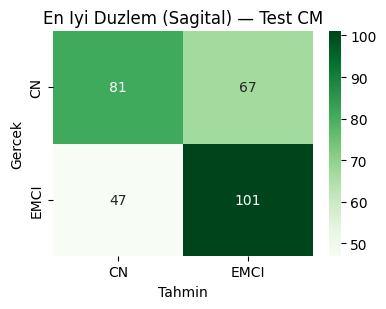

In [ ]:
# ===== EK HUCRE A: VALIDATION'da en iyi DUZLEMI sec, 5-fold ensemble test =====
import numpy as np, os

# Modeller baska oturumda egitildiyse dogru klasoru sabitle:
ANA_KLASOR ='/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04'

DUZLEM_KLASOR = {
    'sagital': os.path.join(ANA_KLASOR, 'Sagital'),
    'aksiyal': os.path.join(ANA_KLASOR, 'Aksiyal'),
    'koronal': os.path.join(ANA_KLASOR, 'Koronal'),
}

# 1) Her duzlemin VALIDATION ortalamasini oku, en iyisini sec (TEST'e gore DEGIL)
val_ort = {}
for d, klasor in DUZLEM_KLASOR.items():
    dfv = pd.read_csv(os.path.join(klasor, 'deney_sonuclari.csv'))
    val_ort[d] = dfv['val_acc'].mean()
    print(f"  {d.capitalize():9s} val_acc ort: {val_ort[d]:.4f}")
en_iyi_duzlem = max(val_ort, key=val_ort.get)
print(f"\nVALIDATION'da en iyi duzlem: {en_iyi_duzlem.upper()}  ({val_ort[en_iyi_duzlem]:.4f})\n")

# 2) Test verisi
test_config = dict(CONFIG)
test_config["kaynak_CN"]   = CONFIG["kaynak_CN_test"]
test_config["kaynak_EMCI"] = CONFIG["kaynak_EMCI_test"]
test_veriler = veri_listesi_olustur(test_config)
sid_true = {f"{x['hasta_id']}_{x['seans_id']}": x['etiket'] for x in test_veriler}

# 3) Sadece o duzlemin 5 fold modelini ortala
klasor = DUZLEM_KLASOR[en_iyi_duzlem]
test_loader = loader_olustur(test_veriler, en_iyi_duzlem, CONFIG, shuffle=False)
toplam = {}
for fold in range(1, CONFIG['k_fold'] + 1):
    m_path = os.path.join(klasor, f'{en_iyi_duzlem}_fold_{fold}.pth')
    model = SinglePlaneModel(dropout_rate=CONFIG['dropout'], hidden_dim=256).to(DEVICE)
    model.load_state_dict(torch.load(m_path, weights_only=True))
    sids, probs = tahmin_al(model, test_loader)
    for sid, pr in zip(sids, probs):
        toplam.setdefault(sid, np.zeros(2)); toplam[sid] += np.array(pr)
    del model; torch.cuda.empty_cache()
avg = {sid: v / CONFIG['k_fold'] for sid, v in toplam.items()}

# 4) Karar + metrikler
y_true, y_pred = [], []
for sid in sorted(avg.keys()):
    y_true.append(sid_true[sid]); y_pred.append(int(np.argmax(avg[sid])))

acc = accuracy_score(y_true, y_pred)
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
p_pc, r_pc, f_pc, _ = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0,1], zero_division=0)
print(f"{'='*60}\nEN IYI DUZLEM ({en_iyi_duzlem.upper()}) 5-FOLD ENSEMBLE — NIHAI TEST\n{'='*60}")
print(f"   Accuracy     : {acc:.4f}")
print(f"   Precision    : {p:.4f} | Recall: {r:.4f} | F1: {f:.4f}")
print(f"   Per-Class F1 : CN={f_pc[0]:.4f} | EMCI={f_pc[1]:.4f}")
print(f"\n{classification_report(y_true, y_pred, target_names=['CN','EMCI'], zero_division=0)}")

plt.figure(figsize=(4,3.2))
sns.heatmap(confusion_matrix(y_true, y_pred, labels=[0,1]), annot=True, fmt='d', cmap='Greens',
            xticklabels=['CN','EMCI'], yticklabels=['CN','EMCI'])
plt.title(f"En Iyi Duzlem ({en_iyi_duzlem.capitalize()}) — Test CM")
plt.xlabel("Tahmin"); plt.ylabel("Gercek"); plt.tight_layout(); plt.show()

Duzlem agirliklari (validation'dan):
   Sagital  : 0.365
   Aksiyal  : 0.290
   Koronal  : 0.345

VAL-AGIRLIKLI DUZLEM ENSEMBLE — NIHAI TEST
   Accuracy     : 0.5878
   Precision    : 0.5916 | Recall: 0.5878 | F1: 0.5836
   Per-Class F1 : CN=0.5414 | EMCI=0.6258

              precision    recall  f1-score   support

          CN       0.61      0.49      0.54       148
        EMCI       0.57      0.69      0.63       148

    accuracy                           0.59       296
   macro avg       0.59      0.59      0.58       296
weighted avg       0.59      0.59      0.58       296



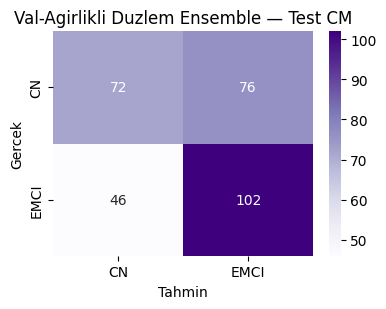

In [ ]:
# ===== EK HUCRE B: VALIDATION accuracy ile DUZLEM-AGIRLIKLI ensemble =====
import numpy as np, os

ANA_KLASOR ='/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04'


DUZLEM_KLASOR = {
    'sagital': os.path.join(ANA_KLASOR, 'Sagital'),
    'aksiyal': os.path.join(ANA_KLASOR, 'Aksiyal'),
    'koronal': os.path.join(ANA_KLASOR, 'Koronal'),
}

# 1) Agirliklar VALIDATION'dan: (val_acc - 0.5) ile zayif duzlem otomatik kisilir
agirlik = {}
for d, klasor in DUZLEM_KLASOR.items():
    dfv = pd.read_csv(os.path.join(klasor, 'deney_sonuclari.csv'))
    agirlik[d] = max(dfv['val_acc'].mean() - 0.5, 0.0)
toplam_ag = sum(agirlik.values())
agirlik = {d: v / toplam_ag for d, v in agirlik.items()}
print("Duzlem agirliklari (validation'dan):")
for d, w in agirlik.items():
    print(f"   {d.capitalize():9s}: {w:.3f}")

# 2) Test verisi
test_config = dict(CONFIG)
test_config["kaynak_CN"]   = CONFIG["kaynak_CN_test"]
test_config["kaynak_EMCI"] = CONFIG["kaynak_EMCI_test"]
test_veriler = veri_listesi_olustur(test_config)
sid_true = {f"{x['hasta_id']}_{x['seans_id']}": x['etiket'] for x in test_veriler}

# 3) Her duzlemin 5-fold ortalamasini al
plane_avg = {}
for d, klasor in DUZLEM_KLASOR.items():
    test_loader = loader_olustur(test_veriler, d, CONFIG, shuffle=False)
    toplam = {}
    for fold in range(1, CONFIG['k_fold'] + 1):
        m_path = os.path.join(klasor, f'{d}_fold_{fold}.pth')
        model = SinglePlaneModel(dropout_rate=CONFIG['dropout'], hidden_dim=256).to(DEVICE)
        model.load_state_dict(torch.load(m_path, weights_only=True))
        sids, probs = tahmin_al(model, test_loader)
        for sid, pr in zip(sids, probs):
            toplam.setdefault(sid, np.zeros(2)); toplam[sid] += np.array(pr)
        del model; torch.cuda.empty_cache()
    plane_avg[d] = {sid: v / CONFIG['k_fold'] for sid, v in toplam.items()}

# 4) Agirlikli birlesim
ortak = set.intersection(*[set(plane_avg[d].keys()) for d in DUZLEM_KLASOR])
y_true, y_pred = [], []
for sid in sorted(ortak):
    fused = np.zeros(2)
    for d in DUZLEM_KLASOR:
        fused += agirlik[d] * plane_avg[d][sid]
    y_true.append(sid_true[sid]); y_pred.append(int(np.argmax(fused)))

acc = accuracy_score(y_true, y_pred)
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
p_pc, r_pc, f_pc, _ = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0,1], zero_division=0)
print(f"\n{'='*60}\nVAL-AGIRLIKLI DUZLEM ENSEMBLE — NIHAI TEST\n{'='*60}")
print(f"   Accuracy     : {acc:.4f}")
print(f"   Precision    : {p:.4f} | Recall: {r:.4f} | F1: {f:.4f}")
print(f"   Per-Class F1 : CN={f_pc[0]:.4f} | EMCI={f_pc[1]:.4f}")
print(f"\n{classification_report(y_true, y_pred, target_names=['CN','EMCI'], zero_division=0)}")

plt.figure(figsize=(4,3.2))
sns.heatmap(confusion_matrix(y_true, y_pred, labels=[0,1]), annot=True, fmt='d', cmap='Purples',
            xticklabels=['CN','EMCI'], yticklabels=['CN','EMCI'])
plt.title("Val-Agirlikli Duzlem Ensemble — Test CM")
plt.xlabel("Tahmin"); plt.ylabel("Gercek"); plt.tight_layout(); plt.show()

15 model agirligi (validation'dan, normalize):
   Aksiyal   fold 1: 0.060
   Aksiyal   fold 2: 0.044
   Aksiyal   fold 3: 0.058
   Aksiyal   fold 4: 0.067
   Aksiyal   fold 5: 0.061
   Koronal   fold 1: 0.079
   Koronal   fold 2: 0.073
   Koronal   fold 3: 0.065
   Koronal   fold 4: 0.065
   Koronal   fold 5: 0.063
   Sagital   fold 1: 0.081
   Sagital   fold 2: 0.070
   Sagital   fold 3: 0.063
   Sagital   fold 4: 0.090
   Sagital   fold 5: 0.060

15-MODEL VAL-AGIRLIKLI ENSEMBLE — NIHAI TEST
   Accuracy     : 0.5912
   Precision    : 0.5954 | Recall: 0.5912 | F1: 0.5867
   Per-Class F1 : CN=0.5434 | EMCI=0.6300

              precision    recall  f1-score   support

          CN       0.62      0.49      0.54       148
        EMCI       0.58      0.70      0.63       148

    accuracy                           0.59       296
   macro avg       0.60      0.59      0.59       296
weighted avg       0.60      0.59      0.59       296



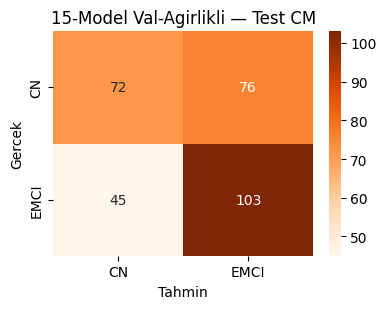

In [ ]:
# ===== EK HUCRE C: 15 MODEL — her (duzlem,fold) modeline KENDI val_acc agirligi =====
import numpy as np, os

ANA_KLASOR ='/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_25D_2026_06_11_10_04'


DUZLEM_KLASOR = {
    'sagital': os.path.join(ANA_KLASOR, 'Sagital'),
    'aksiyal': os.path.join(ANA_KLASOR, 'Aksiyal'),
    'koronal': os.path.join(ANA_KLASOR, 'Koronal'),
}

# 1) Her (duzlem,fold) icin VALIDATION agirligi (val_acc - 0.5)
model_agirlik = {}   # (duzlem, fold) -> agirlik
for d, klasor in DUZLEM_KLASOR.items():
    dfv = pd.read_csv(os.path.join(klasor, 'deney_sonuclari.csv'))
    for _, row in dfv.iterrows():
        model_agirlik[(d, int(row['fold']))] = max(row['val_acc'] - 0.5, 0.0)
toplam_ag = sum(model_agirlik.values())
print("15 model agirligi (validation'dan, normalize):")
for (d, fold), w in sorted(model_agirlik.items()):
    print(f"   {d.capitalize():9s} fold {fold}: {w/toplam_ag:.3f}")

# 2) Test verisi
test_config = dict(CONFIG)
test_config["kaynak_CN"]   = CONFIG["kaynak_CN_test"]
test_config["kaynak_EMCI"] = CONFIG["kaynak_EMCI_test"]
test_veriler = veri_listesi_olustur(test_config)
sid_true = {f"{x['hasta_id']}_{x['seans_id']}": x['etiket'] for x in test_veriler}

# 3) 15 modeli tek tek, kendi agirligiyla topla
toplam_olasilik = {}
for d, klasor in DUZLEM_KLASOR.items():
    test_loader = loader_olustur(test_veriler, d, CONFIG, shuffle=False)
    for fold in range(1, CONFIG['k_fold'] + 1):
        m_path = os.path.join(klasor, f'{d}_fold_{fold}.pth')
        model = SinglePlaneModel(dropout_rate=CONFIG['dropout'], hidden_dim=256).to(DEVICE)
        model.load_state_dict(torch.load(m_path, weights_only=True))
        sids, probs = tahmin_al(model, test_loader)
        w = model_agirlik[(d, fold)] / toplam_ag
        for sid, pr in zip(sids, probs):
            toplam_olasilik.setdefault(sid, np.zeros(2))
            toplam_olasilik[sid] += w * np.array(pr)
        del model; torch.cuda.empty_cache()

# 4) Karar + metrikler
y_true, y_pred = [], []
for sid in sorted(toplam_olasilik.keys()):
    y_true.append(sid_true[sid]); y_pred.append(int(np.argmax(toplam_olasilik[sid])))

acc = accuracy_score(y_true, y_pred)
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
p_pc, r_pc, f_pc, _ = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0,1], zero_division=0)
print(f"\n{'='*60}\n15-MODEL VAL-AGIRLIKLI ENSEMBLE — NIHAI TEST\n{'='*60}")
print(f"   Accuracy     : {acc:.4f}")
print(f"   Precision    : {p:.4f} | Recall: {r:.4f} | F1: {f:.4f}")
print(f"   Per-Class F1 : CN={f_pc[0]:.4f} | EMCI={f_pc[1]:.4f}")
print(f"\n{classification_report(y_true, y_pred, target_names=['CN','EMCI'], zero_division=0)}")

plt.figure(figsize=(4,3.2))
sns.heatmap(confusion_matrix(y_true, y_pred, labels=[0,1]), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['CN','EMCI'], yticklabels=['CN','EMCI'])
plt.title("15-Model Val-Agirlikli — Test CM")
plt.xlabel("Tahmin"); plt.ylabel("Gercek"); plt.tight_layout(); plt.show()